In [1]:
import os, sys, json, shutil, traceback, subprocess
from pathlib import Path
from pprint import pprint
import gzip
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

In [2]:
# DIRs

WORK_NAME = "M01_ds003768"


DATA_ROOT = Path("/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768")
RESULTS_ROOT = DATA_ROOT.parent / "rsCVR_Results"
WORK_ROOT = RESULTS_ROOT / WORK_NAME

INDEX_DIR = WORK_ROOT / "index"
LOG_DIR = WORK_ROOT / "logs"
QC_DIR = WORK_ROOT / "qc"
RAPIDTIDE_DIR = WORK_ROOT / "rapidtide"
SPM_DIR = WORK_ROOT / "spm_preproc"
SUMMARY_DIR = WORK_ROOT / "summary"
MANIFEST_DIR = WORK_ROOT / "manifests"

for d in [RESULTS_ROOT, WORK_ROOT, INDEX_DIR, LOG_DIR, QC_DIR, RAPIDTIDE_DIR, SPM_DIR, SUMMARY_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("WORK_ROOT:", WORK_ROOT)

WORK_ROOT: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768


In [3]:
# defs for JSON saving

def load_json_safe(p):
    p = Path(p)
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(obj, p):
    p = Path(p)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

In [4]:
# SPM-CLI Check

ENV_BIN = Path(sys.executable).parent
os.environ["PATH"] = f"{ENV_BIN}:{os.environ['PATH']}"

SPM_EXE = shutil.which("spm")
print("sys.executable:", sys.executable)
print("SPM_EXE:", SPM_EXE)

assert SPM_EXE is not None, "spm executable not found in current kernel PATH"

sys.executable: /home/bami/anaconda3/envs/JHA-spmCVR/bin/python
SPM_EXE: /home/bami/anaconda3/envs/JHA-spmCVR/bin/spm


In [5]:
# TPM DIR
TPM_PATH = Path("/media/bami/JHA/rsCVR/data/SPM_mask/TPM.nii")
assert TPM_PATH.exists(), f"TPM not found: {TPM_PATH}"

print("TPM_PATH:", TPM_PATH)

TPM_PATH: /media/bami/JHA/rsCVR/data/SPM_mask/TPM.nii


In [6]:
# all_run_specs 재작업

ALL_SUBJECTS = sorted([p.name for p in DATA_ROOT.glob("sub-*") if p.is_dir()])
TARGET_RUNS = ["run-1", "run-2"]

all_run_specs = []
missing_rows = []

for subject in ALL_SUBJECTS:
    subj_dir = DATA_ROOT / subject
    anat_dir = subj_dir / "anat"
    func_dir = subj_dir / "func"

    t1_nii = anat_dir / f"{subject}_T1w.nii.gz"
    t1_json = anat_dir / f"{subject}_T1w.json"

    for run in TARGET_RUNS:
        bold_nii = func_dir / f"{subject}_task-rest_{run}_bold.nii.gz"
        bold_json = func_dir / f"{subject}_task-rest_{run}_bold.json"

        missing = []
        if not t1_nii.exists(): missing.append("t1_nii")
        if not t1_json.exists(): missing.append("t1_json")
        if not bold_nii.exists(): missing.append("bold_nii")
        if not bold_json.exists(): missing.append("bold_json")

        if missing:
            missing_rows.append({
                "subject": subject,
                "run": run,
                "missing": ",".join(missing)
            })
            continue

        meta = load_json_safe(bold_json)

        spm_subject_root = SPM_DIR / subject
        spm_run_dir = spm_subject_root / run
        spm_anat_dir = spm_run_dir / "anat"
        qc_run_dir = QC_DIR / subject / run

        for d in [spm_subject_root, spm_anat_dir, spm_run_dir, qc_run_dir]:
            d.mkdir(parents=True, exist_ok=True)

        spec = {
            "subject": subject,
            "run": run,
            "inputs": {
                "t1_nii": str(t1_nii),
                "t1_json": str(t1_json),
                "bold_nii": str(bold_nii),
                "bold_json": str(bold_json),
                "TR": float(meta.get("RepetitionTime")),
            },
            "outputs": {
                "spm_subject_root": str(spm_subject_root),
                "spm_anat_dir": str(spm_anat_dir),
                "spm_run_dir": str(spm_run_dir),
                "qc_run_dir": str(qc_run_dir),

                "spm_preproc_bold": str(spm_run_dir / f"{subject}_{run}_preproc_bold.nii.gz"),
                "filtered_bold": str(spm_run_dir / f"{subject}_{run}_preproc_bold_dt_filt.nii.gz"),
                "mean_bold_spm": str(spm_run_dir / f"mean{subject}_task-rest_{run}_bold_00001.nii"),
                "mean_bold_manual": str(spm_run_dir / f"{subject}_{run}_mean_after_reslice.nii.gz"),

                "coreg_t1": str(spm_anat_dir / f"r{subject}_T1w.nii"),
                "coreg_job_m": str(spm_run_dir / f"{subject}_{run}_coreg_job.m"),
                "segment_job_m": str(spm_run_dir / f"{subject}_{run}_segment_job.m"),
                "norm_job_m": str(spm_run_dir / f"{subject}_{run}_norm_job.m"),
            }
        }
        all_run_specs.append(spec)

df_missing_specs = pd.DataFrame(missing_rows)
print("Valid runs:", len(all_run_specs))
display(df_missing_specs)

Valid runs: 66


""


In [7]:
## Defines for processing tasks

# def: meanBOLD selection : SPM mean*.nii 우선적용
def pick_mean_bold_for_coreg(spec):
    spm_mean = Path(spec["outputs"]["mean_bold_spm"])
    manual_mean = Path(spec["outputs"]["mean_bold_manual"])
    if spm_mean.exists():
        return spm_mean
    if manual_mean.exists():
        return manual_mean
    raise FileNotFoundError(
        f"No mean BOLD found for {spec['subject']} {spec['run']}\n"
        f"Checked:\n- {spm_mean}\n- {manual_mean}"
    )


# def: unzip T1WI
def prepare_t1_for_spm(spec):
    src_gz = Path(spec["inputs"]["t1_nii"])
    anat_dir = Path(spec["outputs"]["spm_anat_dir"])

    local_gz = anat_dir / src_gz.name
    local_nii = anat_dir / src_gz.name.replace(".nii.gz", ".nii")

    shutil.copy2(src_gz, local_gz)

    if local_nii.exists():
        local_nii.unlink()

    with gzip.open(local_gz, "rb") as f_in, open(local_nii, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

    return {
        "local_gz": str(local_gz),
        "local_nii": str(local_nii),
    }


# def: SPM script runner
def run_spm_job_via_cli(job_m_path, cwd=None):
    job_m_path = Path(job_m_path)

    cmd = [SPM_EXE, "script", str(job_m_path)]

    out = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        cwd=cwd,
        check=False
    )
    return {
        "cmd": cmd,
        "returncode": out.returncode,
        "stdout": out.stdout,
        "stderr": out.stderr,
    }


# def: Coregist batch writer : T1WI (source) --(coregistreation)--> meanBOLD (reference)
def write_spm_coreg_job(reference_img, source_img, other_imgs, job_m_path):
    reference_img = str(Path(reference_img)).replace("\\", "/")
    source_img = str(Path(source_img)).replace("\\", "/")
    other_imgs = [str(Path(p)).replace("\\", "/") for p in other_imgs]
    job_m_path = Path(job_m_path)

    other_block = "\n".join([f"    '{p},1'" for p in other_imgs]) if other_imgs else ""

    if other_block:
        other_txt = f"""matlabbatch{{1}}.spm.spatial.coreg.estwrite.other = {{
{other_block}
}};"""
    else:
        other_txt = "matlabbatch{1}.spm.spatial.coreg.estwrite.other = {''};"

    job_txt = f"""
matlabbatch{{1}}.spm.spatial.coreg.estwrite.ref = {{'{reference_img},1'}};
matlabbatch{{1}}.spm.spatial.coreg.estwrite.source = {{'{source_img},1'}};
{other_txt}

matlabbatch{{1}}.spm.spatial.coreg.estwrite.eoptions.cost_fun = 'nmi';
matlabbatch{{1}}.spm.spatial.coreg.estwrite.eoptions.sep = [4 2];
matlabbatch{{1}}.spm.spatial.coreg.estwrite.eoptions.tol = [0.0200 0.0200 0.0200 0.0010 0.0010 0.0010 0.0100 0.0100 0.0100 0.0010 0.0010 0.0010];
matlabbatch{{1}}.spm.spatial.coreg.estwrite.eoptions.fwhm = [7 7];

matlabbatch{{1}}.spm.spatial.coreg.estwrite.roptions.interp = 4;
matlabbatch{{1}}.spm.spatial.coreg.estwrite.roptions.wrap = [0 0 0];
matlabbatch{{1}}.spm.spatial.coreg.estwrite.roptions.mask = 0;
matlabbatch{{1}}.spm.spatial.coreg.estwrite.roptions.prefix = 'r';

spm('defaults', 'fmri');
spm_jobman('initcfg');
spm_jobman('run', matlabbatch);
"""
    job_m_path.write_text(job_txt.strip() + "\n", encoding="utf-8")
    return job_m_path


# def: Segment batch writer : c1/c2/c3, y_*/iy_* 도출
def write_spm_segment_job(t1_img, tpm_path, job_m_path):
    t1_img = str(Path(t1_img)).replace("\\", "/")
    tpm_path = str(Path(tpm_path)).replace("\\", "/")
    job_m_path = Path(job_m_path)

    job_txt = f"""
matlabbatch{{1}}.spm.spatial.preproc.channel.vols = {{'{t1_img},1'}};
matlabbatch{{1}}.spm.spatial.preproc.channel.biasreg = 0.001;
matlabbatch{{1}}.spm.spatial.preproc.channel.biasfwhm = 60;
matlabbatch{{1}}.spm.spatial.preproc.channel.write = [0 1];

matlabbatch{{1}}.spm.spatial.preproc.tissue(1).tpm = {{'{tpm_path},1'}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(1).ngaus = 1;
matlabbatch{{1}}.spm.spatial.preproc.tissue(1).native = [1 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(1).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(2).tpm = {{'{tpm_path},2'}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(2).ngaus = 1;
matlabbatch{{1}}.spm.spatial.preproc.tissue(2).native = [1 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(2).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(3).tpm = {{'{tpm_path},3'}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(3).ngaus = 2;
matlabbatch{{1}}.spm.spatial.preproc.tissue(3).native = [1 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(3).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(4).tpm = {{'{tpm_path},4'}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(4).ngaus = 3;
matlabbatch{{1}}.spm.spatial.preproc.tissue(4).native = [0 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(4).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(5).tpm = {{'{tpm_path},5'}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(5).ngaus = 4;
matlabbatch{{1}}.spm.spatial.preproc.tissue(5).native = [0 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(5).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.tissue(6).tpm = {{'{tpm_path},6'}};
matlabbatch{{1}}.spm.spatial.preproc.tissue(6).ngaus = 2;
matlabbatch{{1}}.spm.spatial.preproc.tissue(6).native = [0 0];
matlabbatch{{1}}.spm.spatial.preproc.tissue(6).warped = [0 0];

matlabbatch{{1}}.spm.spatial.preproc.warp.mrf = 1;
matlabbatch{{1}}.spm.spatial.preproc.warp.cleanup = 1;
matlabbatch{{1}}.spm.spatial.preproc.warp.reg = [0 0.001 0.5 0.05 0.2];
matlabbatch{{1}}.spm.spatial.preproc.warp.affreg = 'mni';
matlabbatch{{1}}.spm.spatial.preproc.warp.fwhm = 0;
matlabbatch{{1}}.spm.spatial.preproc.warp.samp = 3;
matlabbatch{{1}}.spm.spatial.preproc.warp.write = [1 1];

spm('defaults', 'fmri');
spm_jobman('initcfg');
spm_jobman('run', matlabbatch);
"""
    job_m_path.write_text(job_txt.strip() + "\n", encoding="utf-8")
    return job_m_path


# def: Normalize : coregistered T1WI, c1/c2/c3 --(write)--> MNI space
def write_spm_norm_write_job(deformation_field
                             , images_to_write
                             , job_m_path
                             , bb=None, vox=None, interp=4):
    deformation_field = str(Path(deformation_field)).replace("\\", "/")
    images_to_write = [str(Path(p)).replace("\\", "/") for p in images_to_write]
    job_m_path = Path(job_m_path)

    img_block = "\n".join([f"    '{p},1'" for p in images_to_write])

    if bb is None:
        bb = [[-78, -112, -70], [78, 76, 85]]
    if vox is None:
        vox = [1, 1, 1]

    job_txt = f"""
matlabbatch{{1}}.spm.spatial.normalise.write.subj.def = {{'{deformation_field}'}};
matlabbatch{{1}}.spm.spatial.normalise.write.subj.resample = {{
{img_block}
}};

matlabbatch{{1}}.spm.spatial.normalise.write.woptions.bb = [{bb[0][0]} {bb[0][1]} {bb[0][2]}; {bb[1][0]} {bb[1][1]} {bb[1][2]}];
matlabbatch{{1}}.spm.spatial.normalise.write.woptions.vox = [{vox[0]} {vox[1]} {vox[2]}];
matlabbatch{{1}}.spm.spatial.normalise.write.woptions.interp = {interp};
matlabbatch{{1}}.spm.spatial.normalise.write.woptions.prefix = 'w';

spm('defaults', 'fmri');
spm_jobman('initcfg');
spm_jobman('run', matlabbatch);
"""
    job_m_path.write_text(job_txt.strip() + "\n", encoding="utf-8")
    return job_m_path

In [8]:
# Single-run testing

def run_structural_spm_pipeline_one(spec, tpm_path):
    result = {
        "subject": spec["subject"],
        "run": spec["run"],
        "success": False,
        "coreg": {},
        "segment": {},
        "normalize": {},
        "error": None,
    }

    try:
        mean_bold = pick_mean_bold_for_coreg(spec)
        prepared_t1 = prepare_t1_for_spm(spec)
        local_t1 = Path(prepared_t1["local_nii"])

        spm_run_dir = Path(spec["outputs"]["spm_run_dir"])
        spm_anat_dir = Path(spec["outputs"]["spm_anat_dir"])

        # 1) coreg
        coreg_job = Path(spec["outputs"]["coreg_job_m"])
        write_spm_coreg_job(
            reference_img=mean_bold,
            source_img=local_t1,
            other_imgs=[],
            job_m_path=coreg_job
        )
        coreg_res = run_spm_job_via_cli(coreg_job, cwd=spm_run_dir)
        result["coreg"] = coreg_res

        if coreg_res["returncode"] != 0:
            raise RuntimeError(f"Coreg failed:\n{coreg_res['stdout']}\n{coreg_res['stderr']}")

        coreg_t1 = spm_anat_dir / f"r{local_t1.name}"
        if not coreg_t1.exists():
            raise FileNotFoundError(f"Coregistered T1 not found: {coreg_t1}")

        # 2) segment
        seg_job = Path(spec["outputs"]["segment_job_m"])
        write_spm_segment_job(coreg_t1, tpm_path, seg_job)
        seg_res = run_spm_job_via_cli(seg_job, cwd=spm_run_dir)
        result["segment"] = seg_res

        if seg_res["returncode"] != 0:
            raise RuntimeError(f"Segment failed:\n{seg_res['stdout']}\n{seg_res['stderr']}")

        c1 = coreg_t1.parent / f"c1{coreg_t1.name}"
        c2 = coreg_t1.parent / f"c2{coreg_t1.name}"
        c3 = coreg_t1.parent / f"c3{coreg_t1.name}"
        y = coreg_t1.parent / f"y_{coreg_t1.name}"
        iy = coreg_t1.parent / f"iy_{coreg_t1.name}"

        for p in [c1, c2, c3, y, iy]:
            if not p.exists():
                raise FileNotFoundError(f"Expected output missing: {p}")

        # 3) normalize write
        norm_job = Path(spec["outputs"]["norm_job_m"])
        write_spm_norm_write_job(
            deformation_field=y,
            images_to_write=[coreg_t1, c1, c2, c3],
            job_m_path=norm_job,
            vox=[1, 1, 1],
            interp=4
        )
        norm_res = run_spm_job_via_cli(norm_job, cwd=spm_run_dir)
        result["normalize"] = norm_res

        if norm_res["returncode"] != 0:
            raise RuntimeError(f"Normalize write failed:\n{norm_res['stdout']}\n{norm_res['stderr']}")

        result["outputs"] = {
            "mean_bold": str(mean_bold),
            "local_t1": str(local_t1),
            "coreg_t1": str(coreg_t1),
            "c1": str(c1),
            "c2": str(c2),
            "c3": str(c3),
            "y": str(y),
            "iy": str(iy),
            "wc1": str(coreg_t1.parent / f"wc1{coreg_t1.name}"),
            "wc2": str(coreg_t1.parent / f"wc2{coreg_t1.name}"),
            "wc3": str(coreg_t1.parent / f"wc3{coreg_t1.name}"),
            "wr_t1": str(coreg_t1.parent / f"w{coreg_t1.name}"),
        }

        result["success"] = True
        return result

    except Exception:
        result["error"] = traceback.format_exc()
        return result

test_spec = [s for s in all_run_specs if s["subject"] == "sub-01" and s["run"] == "run-1"][0]
test_result = run_structural_spm_pipeline_one(test_spec, TPM_PATH)
test_result

{'subject': 'sub-01',
 'run': 'run-1',
 'success': True,
 'coreg': {'cmd': ['/home/bami/anaconda3/envs/JHA-spmCVR/bin/spm',
   'script',
   '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_coreg_job.m'],
  'returncode': 0,
  'stdout': "SPM25, version 25.01.02 (standalone)\nMATLAB, version 25.2.0.3177638 (R2025b) Update 5\n ___  ____  __  __                                            \n/ __)(  _ \\(  \\/  )                                           \n\\__ \\ )___/ )    (   Statistical Parametric Mapping           \n(___/(__)  (_/\\/\\_)  SPM25 - https://www.fil.ion.ucl.ac.uk/spm/\n\n\n\n------------------------------------------------------------------------\n13-May-2026 15:21:06 - Running job #1\n------------------------------------------------------------------------\n13-May-2026 15:21:06 - Running 'Coregister: Estimate & Reslice'\n\nSPM25: spm_coreg                                   15:21:06 - 13/05/2026\n=========================

In [9]:
# Single-run test results
print("success:", test_result["success"])
print("error:", test_result["error"])
if test_result["success"]:
    pprint(test_result["outputs"])

success: True
error: None
{'c1': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c1rsub-01_T1w.nii',
 'c2': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c2rsub-01_T1w.nii',
 'c3': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c3rsub-01_T1w.nii',
 'coreg_t1': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/rsub-01_T1w.nii',
 'iy': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/iy_rsub-01_T1w.nii',
 'local_t1': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/sub-01_T1w.nii',
 'mean_bold': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/meansub-01_task-rest_run-1_bold_00001.nii',
 'wc1': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/s

Available outputs:
mean_bold   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/meansub-01_task-rest_run-1_bold_00001.nii
local_t1    : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/sub-01_T1w.nii
coreg_t1    : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/rsub-01_T1w.nii
c1          : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c1rsub-01_T1w.nii
c2          : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c2rsub-01_T1w.nii
c3          : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c3rsub-01_T1w.nii
y           : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/y_rsub-01_T1w.nii
iy          : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_pre

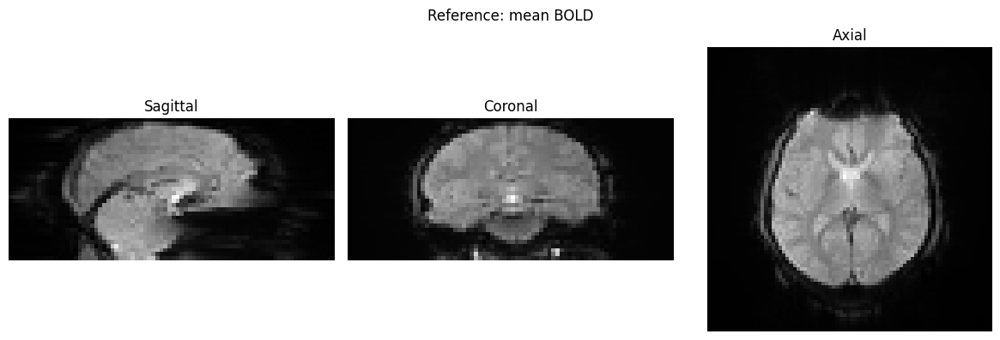

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/meansub-01_task-rest_run-1_bold_00001.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
affine:
 [[-2.98749518e+00  2.47191787e-01 -1.56453252e-01  1.07450157e+02]
 [ 2.51555502e-01  2.98735881e+00 -1.48514748e-01 -1.17810684e+02]
 [-1.07667565e-01  1.20760977e-01  3.99417901e+00 -7.42012634e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


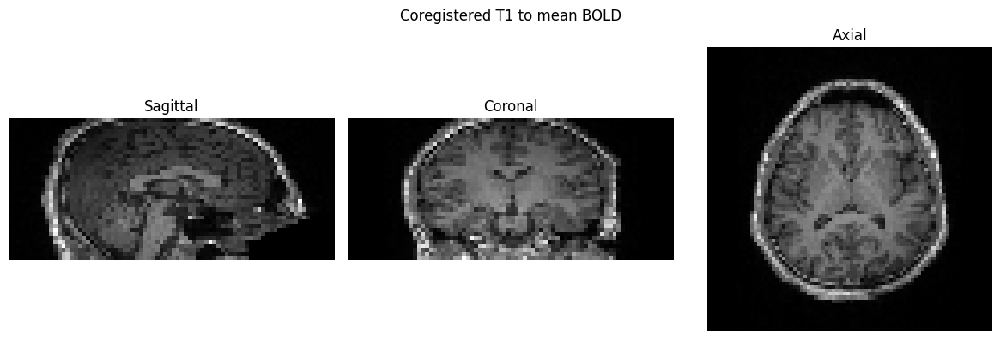

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
affine:
 [[-2.98749518e+00  2.47191787e-01 -1.56453252e-01  1.07450157e+02]
 [ 2.51555502e-01  2.98735881e+00 -1.48514748e-01 -1.17810684e+02]
 [-1.07667565e-01  1.20760977e-01  3.99417901e+00 -7.42012634e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


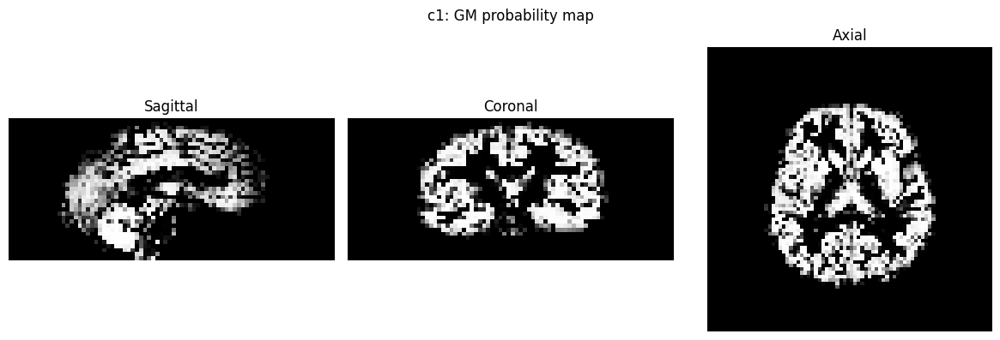

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c1rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
affine:
 [[-2.98749518e+00  2.47191787e-01 -1.56453252e-01  1.07450157e+02]
 [ 2.51555502e-01  2.98735881e+00 -1.48514748e-01 -1.17810684e+02]
 [-1.07667565e-01  1.20760977e-01  3.99417901e+00 -7.42012634e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


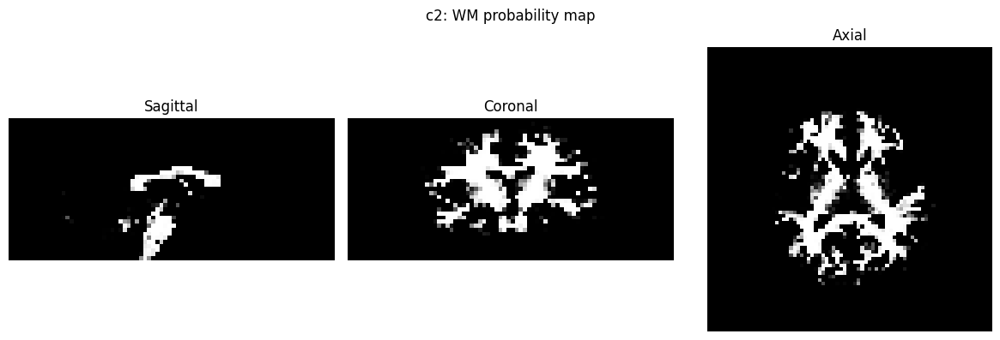

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c2rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
affine:
 [[-2.98749518e+00  2.47191787e-01 -1.56453252e-01  1.07450157e+02]
 [ 2.51555502e-01  2.98735881e+00 -1.48514748e-01 -1.17810684e+02]
 [-1.07667565e-01  1.20760977e-01  3.99417901e+00 -7.42012634e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


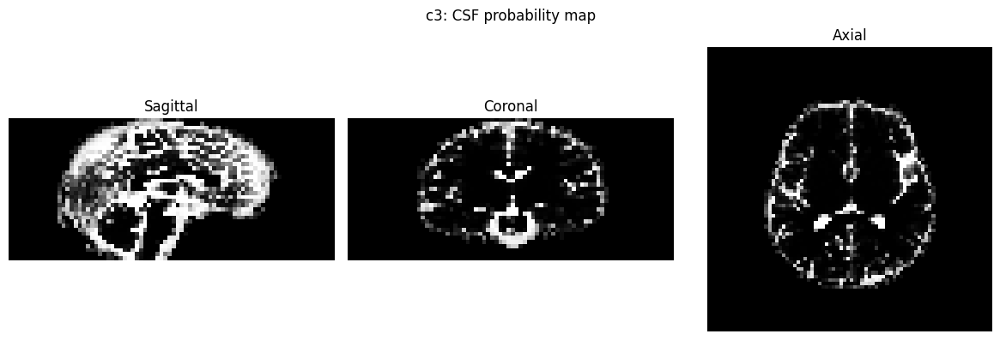

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c3rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))
affine:
 [[-2.98749518e+00  2.47191787e-01 -1.56453252e-01  1.07450157e+02]
 [ 2.51555502e-01  2.98735881e+00 -1.48514748e-01 -1.17810684e+02]
 [-1.07667565e-01  1.20760977e-01  3.99417901e+00 -7.42012634e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


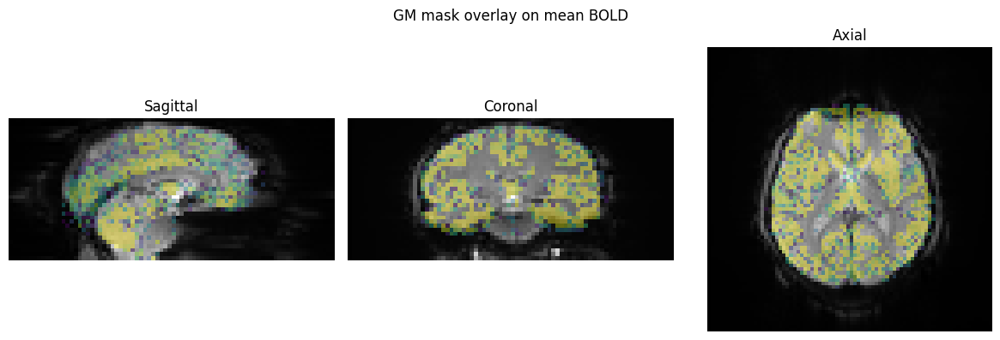

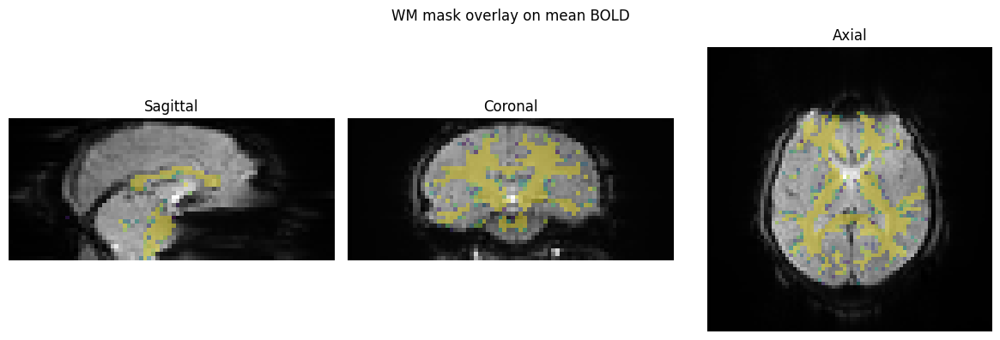

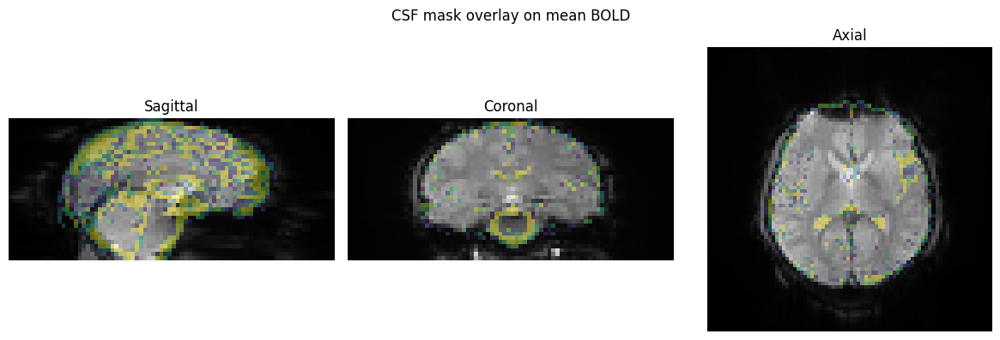


===== y deformation field =====
file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/y_rsub-01_T1w.nii
exists: True
shape: (121, 145, 121, 1, 3)
zooms: (np.float32(1.5), np.float32(1.5), np.float32(1.5), np.float32(0.0), np.float32(0.0))
affine:
 [[  -1.5    0.     0.    90. ]
 [   0.     1.5    0.  -126. ]
 [   0.     0.     1.5  -72. ]
 [   0.     0.     0.     1. ]]

===== iy deformation field =====
file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/iy_rsub-01_T1w.nii
exists: True
shape: (80, 80, 35, 1, 3)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.0), np.float32(0.0))
affine:
 [[-2.98749518e+00  2.47191787e-01 -1.56453252e-01  1.07450157e+02]
 [ 2.51555502e-01  2.98735881e+00 -1.48514748e-01 -1.17810684e+02]
 [-1.07667565e-01  1.20760977e-01  3.99417901e+00 -7.42012634e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [10]:
# Single-run test result VISUALISATION

def _load_3d(path):
    img = nib.load(str(path))
    data = img.get_fdata()

    if data.ndim == 4:
        data = data[..., 0]

    return img, data


def _middle_slices(data):
    x, y, z = data.shape[:3]
    return data[x // 2, :, :], data[:, y // 2, :], data[:, :, z // 2]


def plot_orthogonal_nifti(path, title=None, cmap="gray", vmin=None, vmax=None):
    path = Path(path)
    img, data = _load_3d(path)

    sag, cor, axi = _middle_slices(data)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(np.rot90(sag), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title("Sagittal")
    axes[0].axis("off")

    axes[1].imshow(np.rot90(cor), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title("Coronal")
    axes[1].axis("off")

    axes[2].imshow(np.rot90(axi), cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2].set_title("Axial")
    axes[2].axis("off")

    fig.suptitle(title if title is not None else path.name)
    fig.tight_layout()
    plt.show()

    print("file :", path)
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())
    print("affine:\n", img.affine)


def plot_overlay_mask(base_path, mask_path, title=None, mask_thr=0.2):
    base_path = Path(base_path)
    mask_path = Path(mask_path)

    _, base = _load_3d(base_path)
    _, mask = _load_3d(mask_path)

    if base.shape != mask.shape:
        print("Shape mismatch:")
        print("base:", base.shape, base_path)
        print("mask:", mask.shape, mask_path)
        return

    b_sag, b_cor, b_axi = _middle_slices(base)
    m_sag, m_cor, m_axi = _middle_slices(mask)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, b, m, name in zip(
        axes,
        [b_sag, b_cor, b_axi],
        [m_sag, m_cor, m_axi],
        ["Sagittal", "Coronal", "Axial"]
    ):
        ax.imshow(np.rot90(b), cmap="gray")
        ax.imshow(np.ma.masked_where(np.rot90(m) <= mask_thr, np.rot90(m)), alpha=0.45)
        ax.set_title(name)
        ax.axis("off")

    fig.suptitle(title if title is not None else f"{mask_path.name} overlay")
    fig.tight_layout()
    plt.show()


assert test_result["success"], test_result["error"]

out = test_result["outputs"]

print("Available outputs:")
for k, v in out.items():
    print(f"{k:12s}: {v}")

# meanBOLD / coregistered T1
plot_orthogonal_nifti(
    out["mean_bold"],
    title="Reference: mean BOLD"
)
plot_orthogonal_nifti(
    out["coreg_t1"],
    title="Coregistered T1 to mean BOLD"
)

# c1 (GM) / c2 (WM) / c3 (CSF) : Segmentations
plot_orthogonal_nifti(
    out["c1"],
    title="c1: GM probability map",
    cmap="gray",
    vmin=0,
    vmax=1
)
plot_orthogonal_nifti(
    out["c2"],
    title="c2: WM probability map",
    cmap="gray",
    vmin=0,
    vmax=1
)
plot_orthogonal_nifti(
    out["c3"],
    title="c3: CSF probability map",
    cmap="gray",
    vmin=0,
    vmax=1
)

# Overlay on meanBOLD : c1 (GM) / c2 (WM) / c3 (CSF)
plot_overlay_mask(
    base_path=out["mean_bold"],
    mask_path=out["c1"],
    title="GM mask overlay on mean BOLD",
    mask_thr=0.2
)
plot_overlay_mask(
    base_path=out["mean_bold"],
    mask_path=out["c2"],
    title="WM mask overlay on mean BOLD",
    mask_thr=0.2
)
plot_overlay_mask(
    base_path=out["mean_bold"],
    mask_path=out["c3"],
    title="CSF mask overlay on mean BOLD",
    mask_thr=0.2
)

# y_* / iy_* deformation fields, shapes
for key in ["y", "iy"]:
    p = Path(out[key])
    img = nib.load(str(p))

    print(f"\n===== {key} deformation field =====")
    print("file :", p)
    print("exists:", p.exists())
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())
    print("affine:\n", img.affine)



In [11]:
# Single-to-whole Candidate as batch

def run_structural_spm_pipeline_batch(all_specs, tpm_path):
    results = []
    n_success = 0
    n_fail = 0
    pbar = tqdm(
        all_specs,
        total=len(all_specs),
        desc="Structural SPM batch",
        unit="run"
    )
    for i, spec in enumerate(pbar, start=1):
        subject = spec["subject"]
        run = spec["run"]
        pbar.set_postfix({
            "current": f"{subject} {run}",
            "success": n_success,
            "fail": n_fail
        })
        res = run_structural_spm_pipeline_one(spec, tpm_path)
        results.append(res)
        if res.get("success", False):
            n_success += 1
            last_status = "OK"
        else:
            n_fail += 1
            last_status = "FAIL"
            tqdm.write(f"[FAIL] {subject} {run}")
            if res.get("error") is not None:
                tqdm.write(res["error"][-1500:])
        pbar.set_postfix({
            "last": f"{subject} {run}",
            "status": last_status,
            "success": n_success,
            "fail": n_fail
        })
    print(f"Done. Success: {n_success} / {len(all_specs)}, Fail: {n_fail} / {len(all_specs)}")
    return results

# Execution
batch_struct_results = run_structural_spm_pipeline_batch(all_run_specs, TPM_PATH)
print("Structural batch finished.")

Structural SPM batch:   0%|          | 0/66 [00:00<?, ?run/s]

Done. Success: 66 / 66, Fail: 0 / 66
Structural batch finished.


In [12]:
# Summarise batch execution

summary_rows = []

for res in batch_struct_results:
    out = res.get("outputs", {})

    summary_rows.append({
        "subject": res["subject"],
        "run": res["run"],
        "success": res["success"],
        "error": res["error"],

        "mean_bold": out.get("mean_bold"),
        "local_t1": out.get("local_t1"),
        "coreg_t1": out.get("coreg_t1"),

        "c1": out.get("c1"),
        "c2": out.get("c2"),
        "c3": out.get("c3"),
        "y": out.get("y"),
        "iy": out.get("iy"),

        "wc1": out.get("wc1"),
        "wc2": out.get("wc2"),
        "wc3": out.get("wc3"),
        "wr_t1": out.get("wr_t1"),
    })

df_struct_summary = pd.DataFrame(summary_rows)
print(df_struct_summary["success"].value_counts(dropna=False))
df_struct_summary

success
True    66
Name: count, dtype: int64


,subject,run,success,error,mean_bold,local_t1,coreg_t1,c1,c2,c3,y,iy,wc1,wc2,wc3,wr_t1
0,sub-01,run-1,True,None,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
1,sub-01,run-2,True,None,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
2,sub-02,run-1,True,None,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
3,sub-02,run-2,True,None,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
4,sub-03,run-1,True,None,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,True,None,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
62,sub-32,run-1,True,None,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rs

In [13]:
# Save
struct_summary_csv = SUMMARY_DIR / f"{WORK_NAME}_coreg_segment_norm_summary.csv"
struct_summary_json = SUMMARY_DIR / f"{WORK_NAME}_coreg_segment_norm_summary.json"
df_struct_summary.to_csv(struct_summary_csv, index=False)
save_json(summary_rows, struct_summary_json)

print("Saved:")
print(struct_summary_csv)
print(struct_summary_json)

Saved:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_coreg_segment_norm_summary.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_coreg_segment_norm_summary.json


In [14]:
# Failure confirm
display(df_struct_summary.loc[~df_struct_summary["success"]])

,subject,run,success,error,mean_bold,local_t1,coreg_t1,c1,c2,c3,y,iy,wc1,wc2,wc3,wr_t1


In [18]:
# Check duplicated structural output paths across runs

path_keys = ["coreg_t1", "c1", "c2", "c3", "y", "iy", "wc1", "wc2", "wc3", "wr_t1"]

dup_rows = []

for key in path_keys:
    tmp = (
        df_struct_summary
        .groupby(key)
        .agg(
            n_runs=("run", "count"),
            subjects=("subject", lambda x: sorted(set(x))),
            runs=("run", lambda x: sorted(list(x))),
        )
        .reset_index()
        .rename(columns={key: "path"})
    )
    tmp["file_key"] = key
    tmp = tmp.loc[tmp["n_runs"] > 1]
    dup_rows.append(tmp)

df_duplicate_paths = pd.concat(dup_rows, ignore_index=True)

print("Duplicated structural output paths:", len(df_duplicate_paths))
display(df_duplicate_paths)

Duplicated structural output paths: 0


,path,n_runs,subjects,runs,file_key


In [19]:
# Check whether run-1 and run-2 use separated anat directories

df_struct_summary["anat_dir"] = df_struct_summary["coreg_t1"].apply(
    lambda x: str(Path(x).parent) if pd.notna(x) else None
)

df_anat_dir_check = (
    df_struct_summary
    .groupby("subject")
    .agg(
        n_runs=("run", "count"),
        n_unique_anat_dirs=("anat_dir", "nunique"),
        anat_dirs=("anat_dir", lambda x: sorted(set(x))),
    )
    .reset_index()
)

df_anat_dir_check["separated_by_run"] = (
    df_anat_dir_check["n_runs"] == df_anat_dir_check["n_unique_anat_dirs"]
)

print(df_anat_dir_check["separated_by_run"].value_counts(dropna=False))
display(df_anat_dir_check.loc[~df_anat_dir_check["separated_by_run"]])

separated_by_run
True    33
Name: count, dtype: int64


,subject,n_runs,n_unique_anat_dirs,anat_dirs,separated_by_run


In [20]:
# Visual path check

display(df_struct_summary[[
    "subject", "run", "anat_dir", "coreg_t1", "c1", "y", "wr_t1"
]])

,subject,run,anat_dir,coreg_t1,c1,y,wr_t1
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
...,...,...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...


In [21]:
# Batch processed output integrity check

def check_nifti_file(path, check_data=True):
    path = Path(path) if pd.notna(path) else None

    out = {
        "path": str(path) if path is not None else None,
        "exists": False,
        "loadable": False,
        "shape": None,
        "zooms": None,
        "finite_ratio": None,
        "min": None,
        "max": None,
        "mean": None,
        "std": None,
        "nonzero_ratio": None,
        "error": None,
    }

    try:
        if path is None:
            out["error"] = "path is None"
            return out

        out["exists"] = path.exists()
        if not path.exists():
            out["error"] = "file does not exist"
            return out

        img = nib.load(str(path))
        out["loadable"] = True
        out["shape"] = tuple(img.shape)
        out["zooms"] = tuple(img.header.get_zooms())

        if check_data:
            data = img.get_fdata(dtype=np.float32)
            finite = np.isfinite(data)

            out["finite_ratio"] = float(finite.mean())

            if finite.any():
                vals = data[finite]
                out["min"] = float(vals.min())
                out["max"] = float(vals.max())
                out["mean"] = float(vals.mean())
                out["std"] = float(vals.std())
                out["nonzero_ratio"] = float((np.abs(vals) > 0).mean())

        return out

    except Exception as e:
        out["error"] = str(e)
        return out


file_keys = [
    "mean_bold",
    "local_t1",
    "coreg_t1",
    "c1",
    "c2",
    "c3",
    "y",
    "iy",
    "wc1",
    "wc2",
    "wc3",
    "wr_t1",
]

check_rows = []

for _, row in tqdm(df_struct_summary.iterrows(), total=len(df_struct_summary), desc="Checking NIfTI outputs"):
    for key in file_keys:
        path = row.get(key, None)
        check_data = key not in ["y", "iy"]

        info = check_nifti_file(path, check_data=check_data)
        info.update({
            "subject": row["subject"],
            "run": row["run"],
            "file_key": key,
        })
        check_rows.append(info)

df_struct_file_check = pd.DataFrame(check_rows)

print("Total checked files:", len(df_struct_file_check))

print("\nExists:")
print(df_struct_file_check["exists"].value_counts(dropna=False))

print("\nLoadable:")
print(df_struct_file_check["loadable"].value_counts(dropna=False))

print("\nErrors:")
display(df_struct_file_check.loc[df_struct_file_check["error"].notna()
                                 , ["subject", "run", "file_key", "path", "error"]
                                ])

Checking NIfTI outputs:   0%|          | 0/66 [00:00<?, ?it/s]

Total checked files: 792

Exists:
exists
True    792
Name: count, dtype: int64

Loadable:
loadable
True    792
Name: count, dtype: int64

Errors:


,subject,run,file_key,path,error


In [22]:
# Summaries by file type

df_file_success_summary = (
    df_struct_file_check
    .groupby("file_key")
    .agg(
        n=("file_key", "count"),
        n_exists=("exists", "sum"),
        n_loadable=("loadable", "sum"),
        n_error=("error", lambda x: x.notna().sum()),
    )
    .reset_index()
)

df_file_success_summary["all_exists"] = (
    df_file_success_summary["n_exists"] == df_file_success_summary["n"]
)

df_file_success_summary["all_loadable"] = (
    df_file_success_summary["n_loadable"] == df_file_success_summary["n"]
)

df_file_success_summary

,file_key,n,n_exists,n_loadable,n_error,all_exists,all_loadable
0,c1,66,66,66,0,True,True
1,c2,66,66,66,0,True,True
2,c3,66,66,66,0,True,True
3,coreg_t1,66,66,66,0,True,True
4,iy,66,66,66,0,True,True
5,local_t1,66,66,66,0,True,True
6,mean_bold,66,66,66,0,True,True
7,wc1,66,66,66,0,True,True
8,wc2,66,66,66,0,True,True
9,wc3,66,66,66,0,True,True


In [23]:
# c1/c2/c3 probability map sanity check

df_prob_check = df_struct_file_check.loc[
    df_struct_file_check["file_key"].isin(["c1", "c2", "c3"])
].copy()

df_prob_check["range_ok"] = (
    (df_prob_check["min"] >= -1e-4) &
    (df_prob_check["max"] <= 1.0001)
)

df_prob_check["not_empty"] = (
    df_prob_check["nonzero_ratio"].notna() &
    (df_prob_check["nonzero_ratio"] > 0)
)

df_prob_check["finite_ok"] = (
    df_prob_check["finite_ratio"].notna() &
    (df_prob_check["finite_ratio"] > 0.999)
)

print("range_ok:")
print(df_prob_check["range_ok"].value_counts(dropna=False))

print("\nnot_empty:")
print(df_prob_check["not_empty"].value_counts(dropna=False))

print("\nfinite_ok:")
print(df_prob_check["finite_ok"].value_counts(dropna=False))

display(df_prob_check.loc[
    ~(df_prob_check["range_ok"] & df_prob_check["not_empty"] & df_prob_check["finite_ok"]),
    ["subject", "run", "file_key", "shape", "min", "max", "mean", "std", "nonzero_ratio", "error"]
])

range_ok:
range_ok
True    198
Name: count, dtype: int64

not_empty:
not_empty
True    198
Name: count, dtype: int64

finite_ok:
finite_ok
True    198
Name: count, dtype: int64


,subject,run,file_key,shape,min,max,mean,std,nonzero_ratio,error


In [24]:
# shape consistency check
shape_rows = []

for _, row in df_struct_summary.iterrows():
    subject = row["subject"]
    run = row["run"]

    native_paths = {
        "mean_bold": row["mean_bold"],
        "coreg_t1": row["coreg_t1"],
        "c1": row["c1"],
        "c2": row["c2"],
        "c3": row["c3"],
    }

    norm_paths = {
        "wr_t1": row["wr_t1"],
        "wc1": row["wc1"],
        "wc2": row["wc2"],
        "wc3": row["wc3"],
    }

    native_shapes = {}
    norm_shapes = {}

    for k, p in native_paths.items():
        try:
            native_shapes[k] = tuple(nib.load(str(p)).shape)
        except Exception:
            native_shapes[k] = None

    for k, p in norm_paths.items():
        try:
            norm_shapes[k] = tuple(nib.load(str(p)).shape)
        except Exception:
            norm_shapes[k] = None

    shape_rows.append({
        "subject": subject,
        "run": run,
        "native_shapes": native_shapes,
        "native_same_shape": len(set(native_shapes.values())) == 1,
        "norm_shapes": norm_shapes,
        "norm_same_shape": len(set(norm_shapes.values())) == 1,
    })

df_shape_check = pd.DataFrame(shape_rows)

print("Native-space shape consistency:")
print(df_shape_check["native_same_shape"].value_counts(dropna=False))

print("\nNormalised-space shape consistency:")
print(df_shape_check["norm_same_shape"].value_counts(dropna=False))

display(df_shape_check.loc[
    ~(df_shape_check["native_same_shape"] & df_shape_check["norm_same_shape"])
])

Native-space shape consistency:
native_same_shape
True    66
Name: count, dtype: int64

Normalised-space shape consistency:
norm_same_shape
True    66
Name: count, dtype: int64


,subject,run,native_shapes,native_same_shape,norm_shapes,norm_same_shape


In [25]:
# deformation field check
df_def_check = df_struct_file_check.loc[
    df_struct_file_check["file_key"].isin(["y", "iy"])
].copy()

print("Deformation field exists:")
print(df_def_check["exists"].value_counts(dropna=False))

print("\nDeformation field loadable:")
print(df_def_check["loadable"].value_counts(dropna=False))

print("\nDeformation field shapes:")
display(
    df_def_check
    .groupby(["file_key", "shape"])
    .size()
    .reset_index(name="n")
)

Deformation field exists:
exists
True    132
Name: count, dtype: int64

Deformation field loadable:
loadable
True    132
Name: count, dtype: int64

Deformation field shapes:


,file_key,shape,n
0,iy,"(80, 80, 35, 1, 3)",66
1,y,"(121, 145, 121, 1, 3)",66


In [26]:
# FINAL SUMMARISE

no_duplicate_paths = len(df_duplicate_paths) == 0
all_anat_dirs_separated = df_anat_dir_check["separated_by_run"].all()

all_files_exist = df_struct_file_check["exists"].all()
all_files_loadable = df_struct_file_check["loadable"].all()

prob_ok = (
    df_prob_check["range_ok"].all() and
    df_prob_check["not_empty"].all() and
    df_prob_check["finite_ok"].all()
)

shape_ok = (
    df_shape_check["native_same_shape"].all() and
    df_shape_check["norm_same_shape"].all()
)

def_ok = (
    df_def_check["exists"].all() and
    df_def_check["loadable"].all()
)

print("===== Structural batch output QC =====")
print("No duplicated output paths       :", no_duplicate_paths)
print("Anat dirs separated by run       :", all_anat_dirs_separated)
print("All files exist                  :", all_files_exist)
print("All files loadable               :", all_files_loadable)
print("c1/c2/c3 probability OK          :", prob_ok)
print("Shape consistency OK             :", shape_ok)
print("Deformation fields OK            :", def_ok)

overall_ok = (
    no_duplicate_paths and
    all_anat_dirs_separated and
    all_files_exist and
    all_files_loadable and
    prob_ok and
    shape_ok and
    def_ok
)

print("\nOverall structural output check:", overall_ok)

===== Structural batch output QC =====
No duplicated output paths       : True
Anat dirs separated by run       : True
All files exist                  : True
All files loadable               : True
c1/c2/c3 probability OK          : True
Shape consistency OK             : True
Deformation fields OK            : True

Overall structural output check: True


In [32]:
def load_3d(path):
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    if data.ndim == 4:
        data = data[..., 0]
    return img, data


def get_mid_slices(data):
    x, y, z = data.shape[:3]
    return data[x // 2, :, :], data[:, y // 2, :], data[:, :, z // 2]


def plot_orth(path, title=None, cmap="gray", vmin=None, vmax=None):
    path = Path(path)
    img, data = load_3d(path)
    sag, cor, axi = get_mid_slices(data)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, slc, name in zip(
        axes,
        [sag, cor, axi],
        ["Sagittal", "Coronal", "Axial"]
    ):
        ax.imshow(np.rot90(slc), cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(name)
        ax.axis("off")

    fig.suptitle(title if title else path.name)
    fig.tight_layout()
    plt.show()

    print("file :", path)
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())


def plot_overlay(base_path, mask_path, title=None, mask_thr=0.2):
    _, base = load_3d(base_path)
    _, mask = load_3d(mask_path)

    if base.shape != mask.shape:
        print("Shape mismatch")
        print("base:", base.shape, base_path)
        print("mask:", mask.shape, mask_path)
        return

    b_sag, b_cor, b_axi = get_mid_slices(base)
    m_sag, m_cor, m_axi = get_mid_slices(mask)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, b, m, name in zip(
        axes,
        [b_sag, b_cor, b_axi],
        [m_sag, m_cor, m_axi],
        ["Sagittal", "Coronal", "Axial"]
    ):
        ax.imshow(np.rot90(b), cmap="gray")
        ax.imshow(
            np.ma.masked_where(np.rot90(m) <= mask_thr, np.rot90(m)),
            alpha=0.45
        )
        ax.set_title(name)
        ax.axis("off")

    fig.suptitle(title if title else Path(mask_path).name)
    fig.tight_layout()
    plt.show()

row = df_struct_summary.query("subject == 'sub-01' and run == 'run-1'").iloc[0]
print(row[[
    "mean_bold", "coreg_t1", "c1", "c2", "c3", "y", "iy", "wc1", "wc2", "wc3", "wr_t1"
]])

mean_bold    /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
coreg_t1     /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
c1           /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
c2           /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
c3           /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
y            /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
iy           /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
wc1          /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
wc2          /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
wc3          /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
wr_t1        /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
Name: 0, dtype: object


In [ ]:
## wmeanBOLD, warped mask overlay below -------->

In [42]:
wmean_rows = []

for _, row in tqdm(df_struct_summary.iterrows(), total=len(df_struct_summary), desc="Normalising meanBOLD"):
    subject = row["subject"]
    run = row["run"]

    y_field = Path(row["y"])
    mean_bold = Path(row["mean_bold"])
    run_dir = mean_bold.parent

    job_m_path = run_dir / f"{subject}_{run}_norm_meanbold_job.m"
    wmean_bold = mean_bold.parent / f"w{mean_bold.name}"

    out_row = {
        "subject": subject,
        "run": run,
        "y": str(y_field),
        "mean_bold": str(mean_bold),
        "wmean_bold": str(wmean_bold),
        "wmean_exists": False,
        "returncode": None,
        "error": None,
    }

    try:
        if not y_field.exists():
            raise FileNotFoundError(f"Missing y field: {y_field}")
        if not mean_bold.exists():
            raise FileNotFoundError(f"Missing meanBOLD: {mean_bold}")

        write_spm_norm_write_job(
            deformation_field=y_field,
            images_to_write=[mean_bold],
            job_m_path=job_m_path,
            vox=[1, 1, 1],
            interp=4
        )

        res = run_spm_job_via_cli(job_m_path, cwd=run_dir)
        out_row["returncode"] = res["returncode"]

        if res["returncode"] != 0:
            raise RuntimeError(res["stdout"] + "\n" + res["stderr"])

        out_row["wmean_exists"] = wmean_bold.exists()

        if not wmean_bold.exists():
            raise FileNotFoundError(f"wmeanBOLD was not created: {wmean_bold}")

    except Exception as e:
        out_row["error"] = str(e)

    wmean_rows.append(out_row)

df_wmean_bold = pd.DataFrame(wmean_rows)

print(df_wmean_bold["wmean_exists"].value_counts(dropna=False))
display(df_wmean_bold.loc[~df_wmean_bold["wmean_exists"]])

Normalising meanBOLD:   0%|          | 0/66 [00:00<?, ?it/s]

wmean_exists
True    66
Name: count, dtype: int64


,subject,run,y,mean_bold,wmean_bold,wmean_exists,returncode,error


In [43]:
# Attach wmeanBOLD path to structural summary

df_struct_summary = df_struct_summary.merge(
    df_wmean_bold[["subject", "run", "wmean_bold", "wmean_exists"]],
    on=["subject", "run"],
    how="left"
)

print(df_struct_summary["wmean_exists"].value_counts(dropna=False))
df_struct_summary[["subject", "run", "mean_bold", "wmean_bold", "wmean_exists"]]

wmean_exists
True    66
Name: count, dtype: int64


,subject,run,mean_bold,wmean_bold,wmean_exists
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True


In [44]:
# Check wmeanBOLD files

wmean_check_rows = []

for _, row in df_struct_summary.iterrows():
    info = check_nifti_file(row["wmean_bold"], check_data=True)
    info.update({
        "subject": row["subject"],
        "run": row["run"],
        "file_key": "wmean_bold"
    })
    wmean_check_rows.append(info)

df_wmean_check = pd.DataFrame(wmean_check_rows)

print("Exists:")
print(df_wmean_check["exists"].value_counts(dropna=False))

print("\nLoadable:")
print(df_wmean_check["loadable"].value_counts(dropna=False))

print("\nErrors:")
display(df_wmean_check.loc[df_wmean_check["error"].notna(), [
    "subject", "run", "path", "error"
]])

df_wmean_check

Exists:
exists
True    66
Name: count, dtype: int64

Loadable:
loadable
True    66
Name: count, dtype: int64

Errors:


,subject,run,path,error


,path,exists,loadable,shape,zooms,finite_ratio,min,max,mean,std,nonzero_ratio,error,subject,run,file_key
0,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-99.303726,1523.354492,265.486938,280.510773,0.933065,None,sub-01,run-1,wmean_bold
1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-88.218864,1253.541870,264.476898,276.919952,0.934620,None,sub-01,run-2,wmean_bold
2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-101.715561,1432.279297,311.236328,333.001312,0.929413,None,sub-02,run-1,wmean_bold
3,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-122.264534,1396.876587,309.216156,330.699738,0.919348,None,sub-02,run-2,wmean_bold
4,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-76.446632,1262.903076,271.428558,273.103394,0.961496,None,sub-03,run-1,wmean_bold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-53.649586,1560.802002,290.114410,294.476898,0.919344,None,sub-31,run-2,wmean_bold
62,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-77.474365,1721.086548,263.532196,272.346832,0.925413,None,sub-32,run-1,wmean_bold
63,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-86.191246,1249.105957,263.142853,274.059723,0.935673,None,sub-32,run-2,wmean_bold
64,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(157, 189, 156)","(1.0, 1.0, 1.0)",1.0,-86.106400,1346.753418,319.041351,308.617523,0.948199,None,sub-33,run-1,wmean_bold


In [46]:
# Shape check: wmeanBOLD and wc1/wc2/wc3 should be in the same MNI space

wmean_shape_rows = []

for _, row in df_struct_summary.iterrows():
    paths = {
        "wmean_bold": row["wmean_bold"],
        "wc1": row["wc1"],
        "wc2": row["wc2"],
        "wc3": row["wc3"],
    }

    shapes = {}

    for k, p in paths.items():
        try:
            shapes[k] = tuple(nib.load(str(p)).shape)
        except Exception:
            shapes[k] = None

    wmean_shape_rows.append({
        "subject": row["subject"],
        "run": row["run"],
        "shapes": shapes,
        "same_shape": len(set(shapes.values())) == 1,
    })

df_wmean_shape_check = pd.DataFrame(wmean_shape_rows)

print(df_wmean_shape_check["same_shape"].value_counts(dropna=False))
display(df_wmean_shape_check.loc[~df_wmean_shape_check["same_shape"]])

same_shape
True    66
Name: count, dtype: int64


,subject,run,shapes,same_shape


In [47]:
# Save updated structural summary (with wmeanBOLD)

struct_summary_csv = SUMMARY_DIR / f"{WORK_NAME}_coreg_segment_norm_summary.csv"
struct_summary_json = SUMMARY_DIR / f"{WORK_NAME}_coreg_segment_norm_summary.json"

df_struct_summary.to_csv(struct_summary_csv, index=False)
save_json(df_struct_summary.to_dict(orient="records"), struct_summary_json)

print("Saved updated summary:")
print(struct_summary_csv)
print(struct_summary_json)

Saved updated summary:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_coreg_segment_norm_summary.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_coreg_segment_norm_summary.json


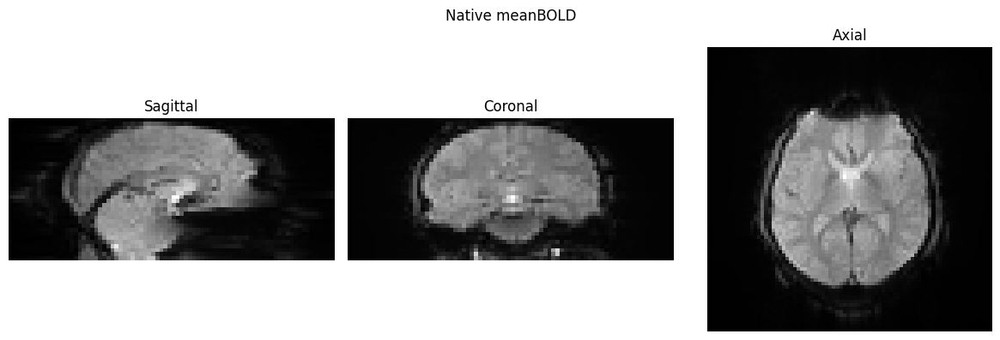

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/meansub-01_task-rest_run-1_bold_00001.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


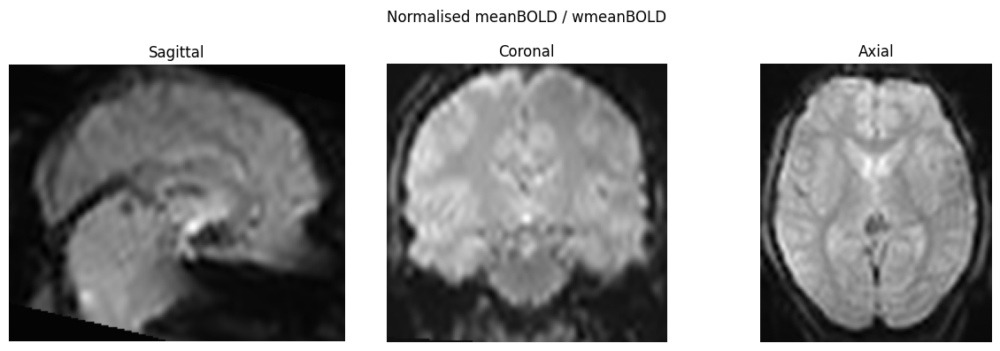

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/wmeansub-01_task-rest_run-1_bold_00001.nii
shape: (157, 189, 156)
zooms: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [48]:
# wmeanBOLD check

row = df_struct_summary.query("subject == 'sub-01' and run == 'run-1'").iloc[0]
plot_orth(row["mean_bold"], title="Native meanBOLD")
plot_orth(row["wmean_bold"], title="Normalised meanBOLD / wmeanBOLD")


===== sub-01 run-1 =====


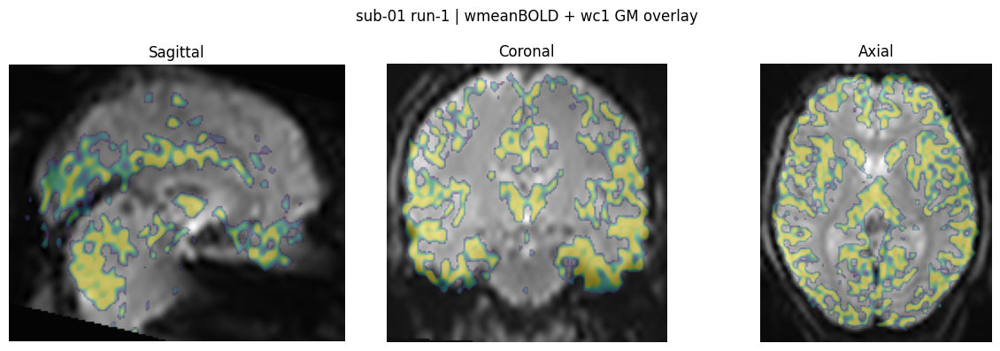

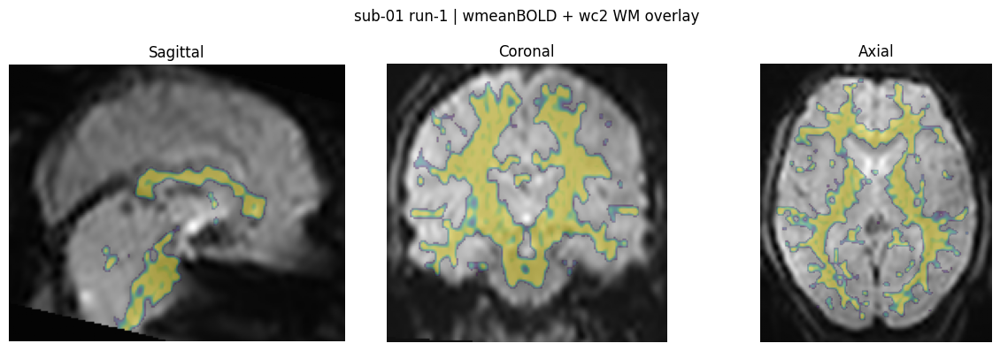

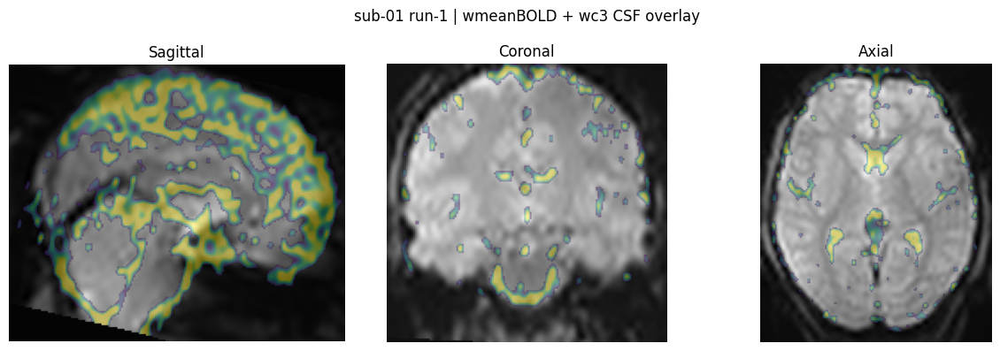


===== sub-02 run-1 =====


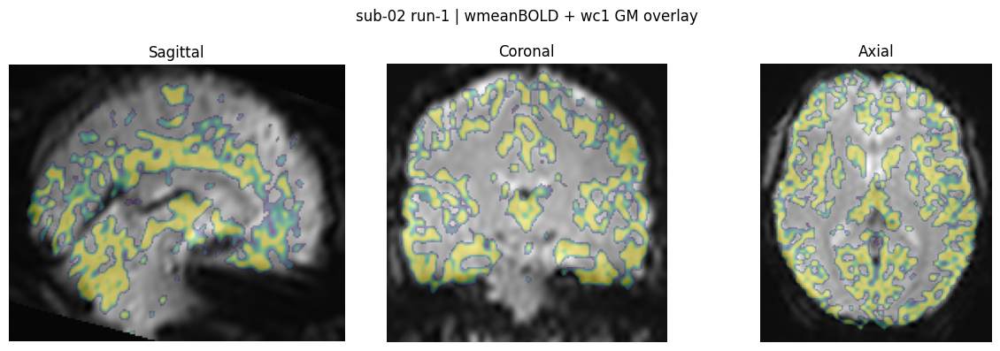

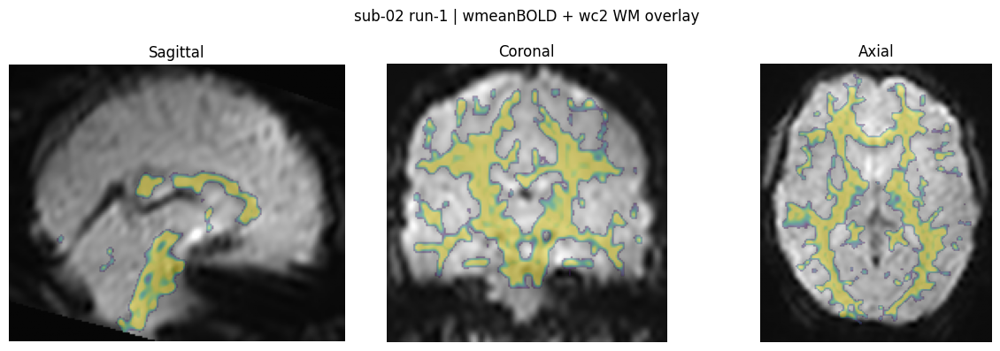

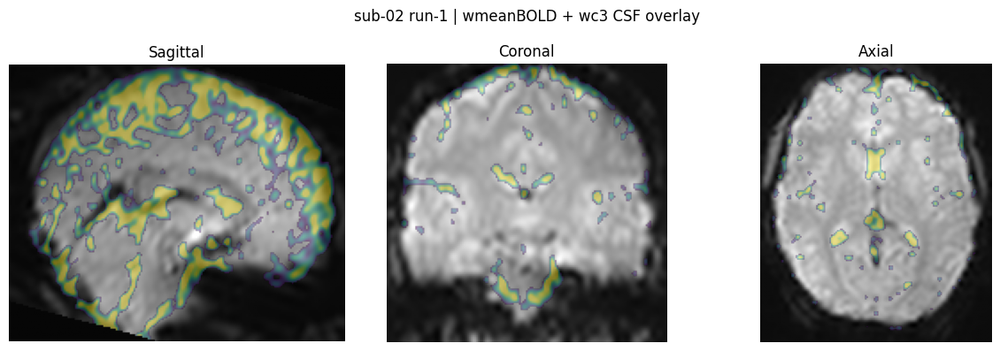


===== sub-03 run-1 =====


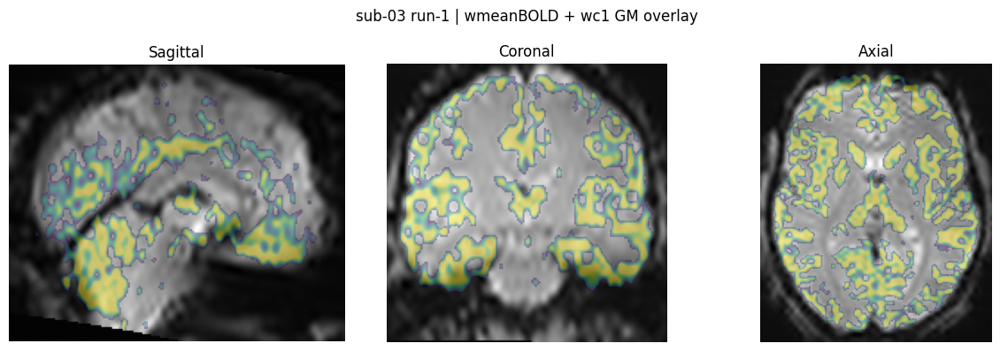

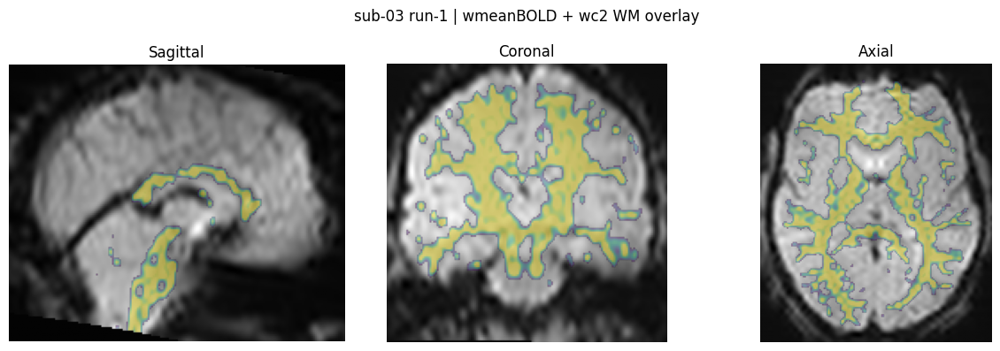

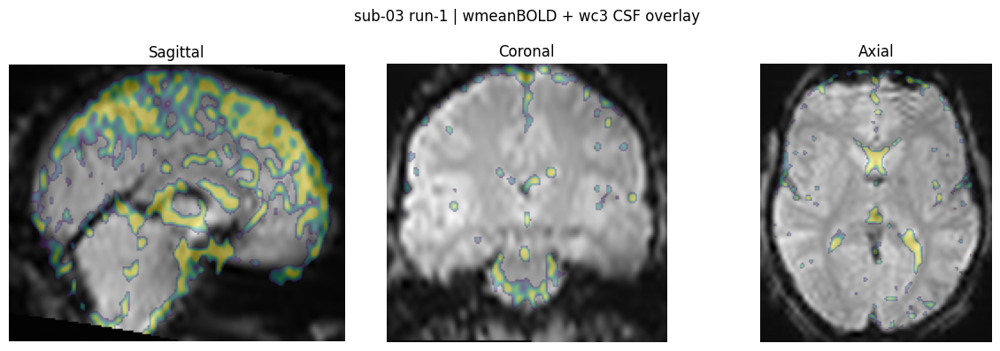


===== sub-04 run-1 =====


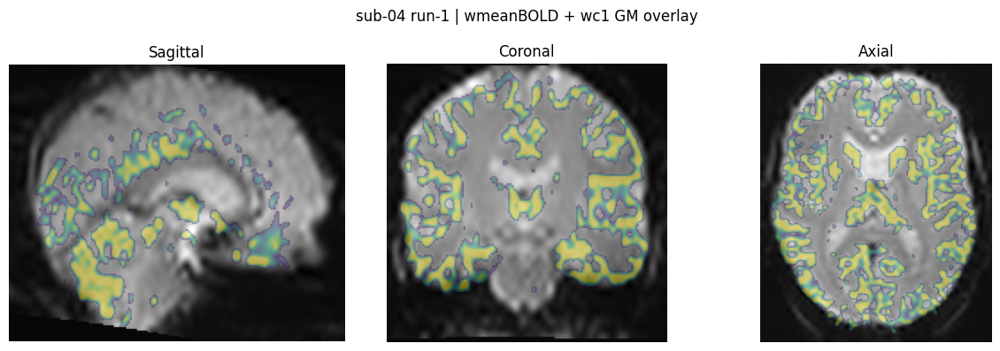

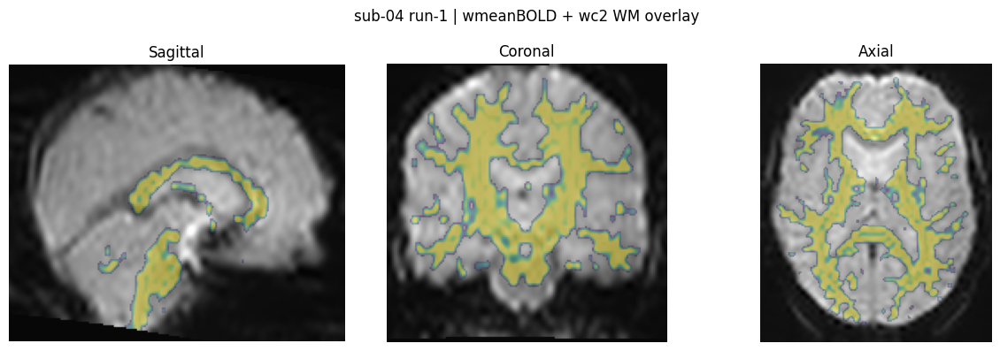

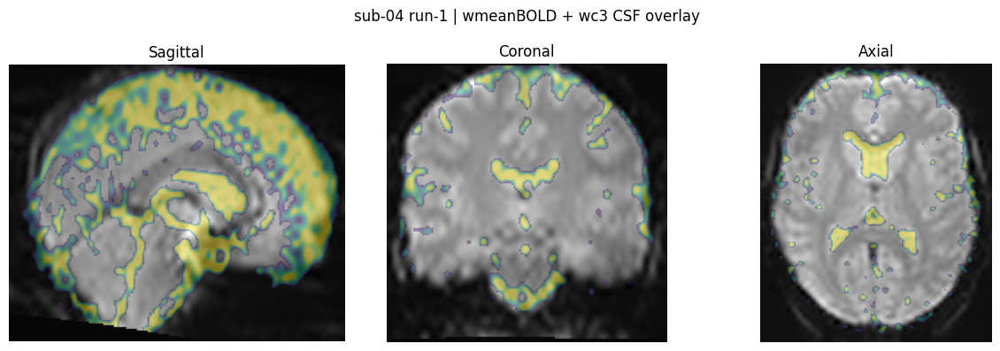


===== sub-05 run-1 =====


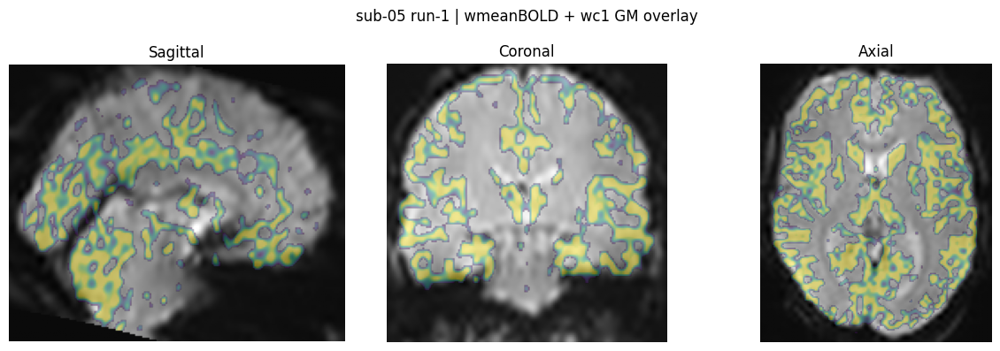

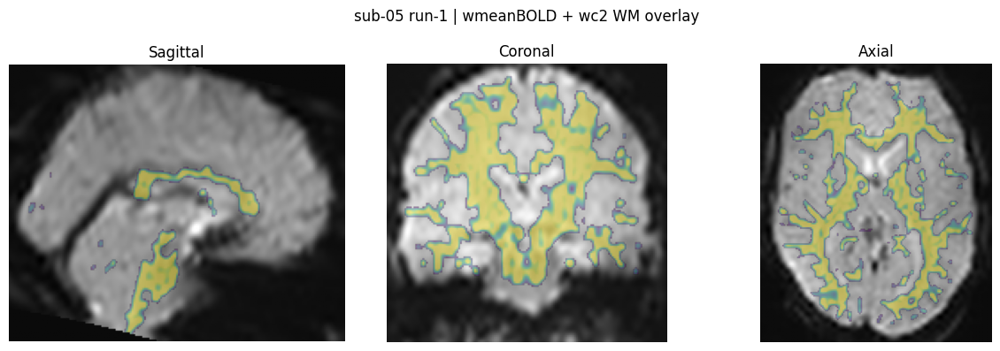

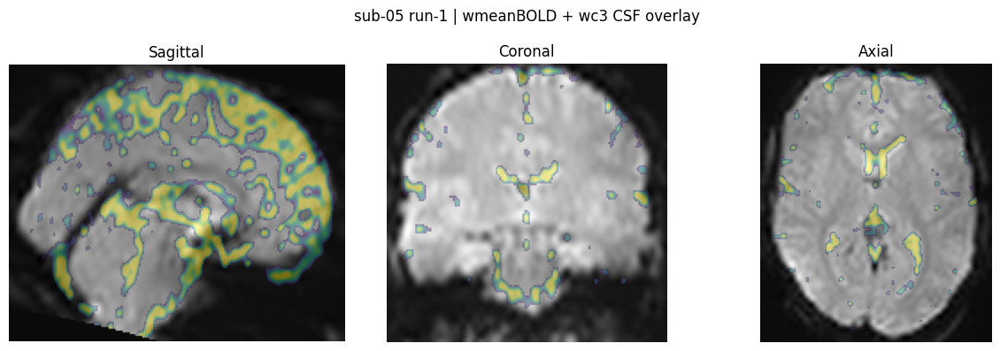

In [49]:
# wmeanBOLD --> wc1/wc2/wc3 overlay

thr = 0.5

sample_rows = (
    df_struct_summary
    .sort_values(["subject", "run"])
    .groupby("subject")
    .head(1)
    .head(5)
)

for _, row in sample_rows.iterrows():
    title_prefix = f"{row['subject']} {row['run']}"

    print(f"\n===== {title_prefix} =====")
    plot_overlay(row["wmean_bold"], row["wc1"], title=f"{title_prefix} | wmeanBOLD + wc1 GM overlay", mask_thr=thr)
    plot_overlay(row["wmean_bold"], row["wc2"], title=f"{title_prefix} | wmeanBOLD + wc2 WM overlay", mask_thr=thr)
    plot_overlay(row["wmean_bold"], row["wc3"], title=f"{title_prefix} | wmeanBOLD + wc3 CSF overlay", mask_thr=thr)

In [52]:
## Slice thichness confirm
# Check spatial resolution / slice thickness of BOLD-derived images

voxel_rows = []

for _, row in df_struct_summary.iterrows():
    mean_img = nib.load(row["mean_bold"])
    coreg_img = nib.load(row["coreg_t1"])

    voxel_rows.append({
        "subject": row["subject"],
        "run": row["run"],
        "mean_bold_shape": mean_img.shape,
        "mean_bold_zooms": mean_img.header.get_zooms(),
        "coreg_t1_shape": coreg_img.shape,
        "coreg_t1_zooms": coreg_img.header.get_zooms(),
    })

df_voxel_check = pd.DataFrame(voxel_rows)
df_voxel_check

,subject,run,mean_bold_shape,mean_bold_zooms,coreg_t1_shape,coreg_t1_zooms
0,sub-01,run-1,"(80, 80, 35)","(3.0, 3.0, 4.0)","(80, 80, 35)","(3.0, 3.0, 4.0)"
1,sub-01,run-2,"(80, 80, 35)","(3.0, 3.0, 4.0)","(80, 80, 35)","(3.0, 3.0, 4.0)"
2,sub-02,run-1,"(80, 80, 35)","(3.0, 2.9999998, 3.9999998)","(80, 80, 35)","(3.0, 2.9999998, 3.9999998)"
3,sub-02,run-2,"(80, 80, 35)","(3.0, 2.9999998, 3.9999998)","(80, 80, 35)","(3.0, 2.9999998, 3.9999998)"
4,sub-03,run-1,"(80, 80, 35)","(2.9999998, 3.0, 3.9999998)","(80, 80, 35)","(2.9999998, 3.0, 3.9999998)"
...,...,...,...,...,...,...
61,sub-31,run-2,"(80, 80, 35)","(3.0, 3.0000002, 4.0)","(80, 80, 35)","(3.0, 3.0000002, 4.0)"
62,sub-32,run-1,"(80, 80, 35)","(3.0, 3.0, 3.9999998)","(80, 80, 35)","(3.0, 3.0, 3.9999998)"
63,sub-32,run-2,"(80, 80, 35)","(3.0, 3.0, 3.9999998)","(80, 80, 35)","(3.0, 3.0, 3.9999998)"
64,sub-33,run-1,"(80, 80, 35)","(3.0, 3.0000002, 4.0)","(80, 80, 35)","(3.0, 3.0000002, 4.0)"


In [53]:
df_voxel_check["mean_bold_zooms"].value_counts()

mean_bold_zooms
(3.0, 3.0, 4.0)                16
(3.0, 3.0, 3.9999998)          10
(2.9999998, 3.0, 4.0)           8
(3.0, 3.0000002, 4.0)           8
(3.0, 2.9999998, 4.0)           6
(2.9999998, 3.0, 3.9999998)     4
(3.0000002, 3.0, 4.0)           4
(3.0, 2.9999998, 3.9999998)     2
(3.0000002, 3.0, 3.9999998)     2
(2.9999998, 3.0, 3.9999995)     2
(3.0, 3.0000002, 4.0000005)     2
(3.0, 3.0, 3.9999995)           2
Name: count, dtype: int64

In [ ]:
## Partial Smoothing :: 3*3*4mm BOLD --> [4, 4, 4]mm

In [54]:
SMOOTH_FWHM = [4, 4, 4]
SMOOTH_TAG = "sm4"

print("SMOOTH_FWHM:", SMOOTH_FWHM)
print("SMOOTH_TAG :", SMOOTH_TAG)

SMOOTH_FWHM: [4, 4, 4]
SMOOTH_TAG : sm4


In [55]:
def gunzip_nifti_if_needed(in_path, out_path):
    in_path = Path(in_path)
    out_path = Path(out_path)

    if out_path.exists():
        out_path.unlink()

    if str(in_path).endswith(".nii.gz"):
        with gzip.open(in_path, "rb") as f_in, open(out_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    else:
        shutil.copy2(in_path, out_path)

    return out_path


def write_spm_smooth_4d_job(in_nii, job_m_path, fwhm=(4, 4, 4), prefix="s"):
    in_nii = Path(in_nii)
    job_m_path = Path(job_m_path)

    img = nib.load(str(in_nii))

    if len(img.shape) == 4:
        nt = img.shape[3]
        scan_block = "\n".join([
            f"    '{str(in_nii).replace(chr(92), '/')},{i}'"
            for i in range(1, nt + 1)
        ])
    else:
        scan_block = f"    '{str(in_nii).replace(chr(92), '/')},1'"

    job_txt = f"""
matlabbatch{{1}}.spm.spatial.smooth.data = {{
{scan_block}
}};
matlabbatch{{1}}.spm.spatial.smooth.fwhm = [{fwhm[0]} {fwhm[1]} {fwhm[2]}];
matlabbatch{{1}}.spm.spatial.smooth.dtype = 0;
matlabbatch{{1}}.spm.spatial.smooth.im = 0;
matlabbatch{{1}}.spm.spatial.smooth.prefix = '{prefix}';

spm('defaults', 'fmri');
spm_jobman('initcfg');
spm_jobman('run', matlabbatch);
"""

    job_m_path.write_text(job_txt.strip() + "\n", encoding="utf-8")
    return job_m_path

In [56]:
# Single-run test: filtered_bold --> SPM smoothing only

test_spec = all_run_specs[0]

subject = test_spec["subject"]
run = test_spec["run"]

spm_run_dir = Path(test_spec["outputs"]["spm_run_dir"])

filtered_bold_gz = Path(test_spec["outputs"]["filtered_bold"])

smooth_input_nii = spm_run_dir / f"{subject}_{run}_filtered_bold_for_smooth.nii"
smooth_job_m = spm_run_dir / f"{subject}_{run}_smooth_{SMOOTH_TAG}_filtered_job.m"

smoothed_filtered_bold = spm_run_dir / f"{subject}_{run}_preproc_bold_dt_filt_{SMOOTH_TAG}.nii.gz"

print("subject:", subject)
print("run    :", run)
print("input  :", filtered_bold_gz)
print("output :", smoothed_filtered_bold)

assert filtered_bold_gz.exists(), f"Missing filtered_bold: {filtered_bold_gz}"

gunzip_nifti_if_needed(filtered_bold_gz, smooth_input_nii)

write_spm_smooth_4d_job(
    in_nii=smooth_input_nii,
    job_m_path=smooth_job_m,
    fwhm=SMOOTH_FWHM,
    prefix="s"
)

smooth_res = run_spm_job_via_cli(smooth_job_m, cwd=spm_run_dir)

print("returncode:", smooth_res["returncode"])
print(smooth_res["stdout"][-1000:])
print(smooth_res["stderr"][-1000:])

if smooth_res["returncode"] != 0:
    raise RuntimeError(smooth_res["stdout"] + "\n" + smooth_res["stderr"])

spm_smoothed_nii = smooth_input_nii.parent / f"s{smooth_input_nii.name}"

print("SPM output:", spm_smoothed_nii)
print("exists    :", spm_smoothed_nii.exists())

if not spm_smoothed_nii.exists():
    raise FileNotFoundError(f"SPM smoothed output not found: {spm_smoothed_nii}")

img_s = nib.load(str(spm_smoothed_nii))
nib.save(img_s, str(smoothed_filtered_bold))

print("Saved standard output:")
print(smoothed_filtered_bold)
print("exists:", smoothed_filtered_bold.exists())

subject: sub-01
run    : run-1
input  : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_preproc_bold_dt_filt.nii.gz
output : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_preproc_bold_dt_filt_sm4.nii.gz
returncode: 0
SPM25, version 25.01.02 (standalone)
MATLAB, version 25.2.0.3177638 (R2025b) Update 5
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM25 - https://www.fil.ion.ucl.ac.uk/spm/



------------------------------------------------------------------------
01-Jun-2026 14:11:17 - Running job #1
------------------------------------------------------------------------
01-Jun-2026 14:11:17 - Running 'Smooth'
01-Jun-2026 14:11:26 - Done    'Smooth'
01-Jun-2026 14:11:26 - Done



SPM output: /media/bami/JHA/rsCVR/da

In [57]:
# Single-run shape check

for p in [filtered_bold_gz, smooth_input_nii, spm_smoothed_nii, smoothed_filtered_bold]:
    img = nib.load(str(p))
    print("\n", p.name)
    print("shape:", img.shape)
    print("zooms:", img.header.get_zooms())


 sub-01_run-1_preproc_bold_dt_filt.nii.gz
shape: (80, 80, 35, 286)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.0))

 sub-01_run-1_filtered_bold_for_smooth.nii
shape: (80, 80, 35, 286)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.0))

 ssub-01_run-1_filtered_bold_for_smooth.nii
shape: (80, 80, 35, 286)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.0))

 sub-01_run-1_preproc_bold_dt_filt_sm4.nii.gz
shape: (80, 80, 35, 286)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.0))


In [58]:
# Batch smoothing

def run_smoothing_filtered_bold_one(spec, fwhm=(4, 4, 4), smooth_tag="sm4", cleanup_temp=False):
    subject = spec["subject"]
    run = spec["run"]

    spm_run_dir = Path(spec["outputs"]["spm_run_dir"])
    filtered_bold_gz = Path(spec["outputs"]["filtered_bold"])

    smooth_input_nii = spm_run_dir / f"{subject}_{run}_filtered_bold_for_smooth.nii"
    smooth_job_m = spm_run_dir / f"{subject}_{run}_smooth_{smooth_tag}_filtered_job.m"

    smoothed_filtered_bold = spm_run_dir / f"{subject}_{run}_preproc_bold_dt_filt_{smooth_tag}.nii.gz"

    row = {
        "subject": subject,
        "run": run,
        "fwhm": str(list(fwhm)),
        "filtered_bold": str(filtered_bold_gz),
        "smooth_input_nii": str(smooth_input_nii),
        "smooth_job_m": str(smooth_job_m),
        "spm_smoothed_nii": None,
        "smoothed_filtered_bold": str(smoothed_filtered_bold),
        "success": False,
        "returncode": None,
        "error": None,
    }

    try:
        if not filtered_bold_gz.exists():
            raise FileNotFoundError(f"Missing filtered_bold: {filtered_bold_gz}")

        gunzip_nifti_if_needed(filtered_bold_gz, smooth_input_nii)

        write_spm_smooth_4d_job(
            in_nii=smooth_input_nii,
            job_m_path=smooth_job_m,
            fwhm=fwhm,
            prefix="s"
        )

        smooth_res = run_spm_job_via_cli(smooth_job_m, cwd=spm_run_dir)
        row["returncode"] = smooth_res["returncode"]

        if smooth_res["returncode"] != 0:
            raise RuntimeError(smooth_res["stdout"] + "\n" + smooth_res["stderr"])

        spm_smoothed_nii = smooth_input_nii.parent / f"s{smooth_input_nii.name}"
        row["spm_smoothed_nii"] = str(spm_smoothed_nii)

        if not spm_smoothed_nii.exists():
            raise FileNotFoundError(f"SPM smoothed output not found: {spm_smoothed_nii}")

        img_s = nib.load(str(spm_smoothed_nii))
        nib.save(img_s, str(smoothed_filtered_bold))

        if not smoothed_filtered_bold.exists():
            raise FileNotFoundError(f"Missing final smoothed output: {smoothed_filtered_bold}")

        # Sanity check: shape should be preserved
        in_shape = nib.load(str(filtered_bold_gz)).shape
        out_shape = nib.load(str(smoothed_filtered_bold)).shape

        if in_shape != out_shape:
            raise ValueError(f"Shape changed after smoothing: input={in_shape}, output={out_shape}")

        row["success"] = True

        if cleanup_temp:
            for p in [smooth_input_nii, spm_smoothed_nii]:
                if Path(p).exists():
                    Path(p).unlink()

    except Exception as e:
        row["error"] = str(e)

    return row


# Execution
smooth_rows = []

for spec in tqdm(all_run_specs, total=len(all_run_specs), desc=f"SPM smoothing {SMOOTH_TAG}"):
    res = run_smoothing_filtered_bold_one(
        spec,
        fwhm=SMOOTH_FWHM,
        smooth_tag=SMOOTH_TAG,
        cleanup_temp=False
    )
    smooth_rows.append(res)

df_smoothing_summary = pd.DataFrame(smooth_rows)

print(df_smoothing_summary["success"].value_counts(dropna=False))
display(df_smoothing_summary.loc[~df_smoothing_summary["success"]])
df_smoothing_summary

SPM smoothing sm4:   0%|          | 0/66 [00:00<?, ?it/s]

success
True    66
Name: count, dtype: int64


,subject,run,fwhm,filtered_bold,smooth_input_nii,smooth_job_m,spm_smoothed_nii,smoothed_filtered_bold,success,returncode,error


,subject,run,fwhm,filtered_bold,smooth_input_nii,smooth_job_m,spm_smoothed_nii,smoothed_filtered_bold,success,returncode,error
0,sub-01,run-1,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
1,sub-01,run-2,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
2,sub-02,run-1,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
3,sub-02,run-2,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
4,sub-03,run-1,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
62,sub-32,run-1,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
63,sub-32,run-2,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None
64,sub-33,run-1,"[4, 4, 4]",/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,0,None


In [59]:
# Check output
smooth_check_rows = []

for _, row in tqdm(df_smoothing_summary.iterrows(), total=len(df_smoothing_summary), desc="Checking smoothed BOLD"):
    p = Path(row["smoothed_filtered_bold"])

    out = {
        "subject": row["subject"],
        "run": row["run"],
        "path": str(p),
        "exists": p.exists(),
        "loadable": False,
        "shape": None,
        "zooms": None,
        "finite_ratio": None,
        "min": None,
        "max": None,
        "mean": None,
        "std": None,
        "error": None,
    }

    try:
        img = nib.load(str(p))
        data = img.get_fdata(dtype=np.float32)

        out["loadable"] = True
        out["shape"] = tuple(img.shape)
        out["zooms"] = tuple(img.header.get_zooms())

        finite = np.isfinite(data)
        out["finite_ratio"] = float(finite.mean())

        if finite.any():
            vals = data[finite]
            out["min"] = float(vals.min())
            out["max"] = float(vals.max())
            out["mean"] = float(vals.mean())
            out["std"] = float(vals.std())

    except Exception as e:
        out["error"] = str(e)

    smooth_check_rows.append(out)

df_smoothing_file_check = pd.DataFrame(smooth_check_rows)

print("Exists:")
print(df_smoothing_file_check["exists"].value_counts(dropna=False))

print("\nLoadable:")
print(df_smoothing_file_check["loadable"].value_counts(dropna=False))

print("\nErrors:")
display(df_smoothing_file_check.loc[df_smoothing_file_check["error"].notna()])

df_smoothing_file_check

Checking smoothed BOLD:   0%|          | 0/66 [00:00<?, ?it/s]

Exists:
exists
True    66
Name: count, dtype: int64

Loadable:
loadable
True    66
Name: count, dtype: int64

Errors:


,subject,run,path,exists,loadable,shape,zooms,finite_ratio,min,max,mean,std,error


,subject,run,path,exists,loadable,shape,zooms,finite_ratio,min,max,mean,std,error
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 3.0, 4.0, 0.0)",1.0,-163.803864,388.048859,-0.000219,3.500742,None
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 3.0, 4.0, 0.0)",1.0,-263.871979,172.960388,-0.000310,3.637768,None
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 2.9999998, 3.9999998, 0.0)",1.0,-243.413925,182.721420,-0.000215,3.036899,None
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 2.9999998, 3.9999998, 0.0)",1.0,-289.930786,303.260956,-0.000085,3.753186,None
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(2.9999998, 3.0, 3.9999998, 0.0)",1.0,-257.085205,308.386871,0.001182,3.825535,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 3.0000002, 4.0, 0.0)",1.0,-243.342407,313.164734,0.000015,4.729271,None
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 3.0, 3.9999998, 0.0)",1.0,-210.668442,423.608673,0.000803,4.371250,None
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 3.0, 3.9999998, 0.0)",1.0,-231.196655,246.675262,-0.000186,3.612405,None
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,"(80, 80, 35, 286)","(3.0, 3.0000002, 4.0, 0.0)",1.0,-191.721375,392.139038,-0.000089,3.874733,None


In [60]:
# Compare with before
shape_rows = []

for _, row in df_smoothing_summary.iterrows():
    filtered_bold = Path(row["filtered_bold"])
    smoothed_bold = Path(row["smoothed_filtered_bold"])

    try:
        img_f = nib.load(str(filtered_bold))
        img_s = nib.load(str(smoothed_bold))

        shape_rows.append({
            "subject": row["subject"],
            "run": row["run"],
            "filtered_shape": tuple(img_f.shape),
            "smoothed_shape": tuple(img_s.shape),
            "filtered_zooms": tuple(img_f.header.get_zooms()),
            "smoothed_zooms": tuple(img_s.header.get_zooms()),
            "same_shape": tuple(img_f.shape) == tuple(img_s.shape),
            "same_zooms": tuple(img_f.header.get_zooms()) == tuple(img_s.header.get_zooms()),
        })

    except Exception as e:
        shape_rows.append({
            "subject": row["subject"],
            "run": row["run"],
            "filtered_shape": None,
            "smoothed_shape": None,
            "filtered_zooms": None,
            "smoothed_zooms": None,
            "same_shape": False,
            "same_zooms": False,
            "error": str(e),
        })

df_smoothing_shape_check = pd.DataFrame(shape_rows)

print("same_shape:")
print(df_smoothing_shape_check["same_shape"].value_counts(dropna=False))

print("\nsame_zooms:")
print(df_smoothing_shape_check["same_zooms"].value_counts(dropna=False))

display(df_smoothing_shape_check.loc[
    ~(df_smoothing_shape_check["same_shape"] & df_smoothing_shape_check["same_zooms"])
])

same_shape:
same_shape
True    66
Name: count, dtype: int64

same_zooms:
same_zooms
True    66
Name: count, dtype: int64


,subject,run,filtered_shape,smoothed_shape,filtered_zooms,smoothed_zooms,same_shape,same_zooms


In [61]:
# Add to summary

df_struct_summary = df_struct_summary.merge(
    df_smoothing_summary[[
        "subject",
        "run",
        "smoothed_filtered_bold",
        "success"
    ]].rename(columns={"success": "smoothing_success"}),
    on=["subject", "run"],
    how="left"
)

print(df_struct_summary["smoothing_success"].value_counts(dropna=False))

df_struct_summary[[
    "subject",
    "run",
    "smoothed_filtered_bold",
    "smoothing_success"
]]

smoothing_success
True    66
Name: count, dtype: int64


,subject,run,smoothed_filtered_bold,smoothing_success
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
...,...,...,...,...
61,sub-31,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
62,sub-32,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
63,sub-32,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
64,sub-33,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True


In [62]:
# SAVE summary

smoothing_summary_csv = SUMMARY_DIR / f"{WORK_NAME}_spm_smoothing_{SMOOTH_TAG}_summary.csv"
smoothing_summary_json = SUMMARY_DIR / f"{WORK_NAME}_spm_smoothing_{SMOOTH_TAG}_summary.json"

df_smoothing_summary.to_csv(smoothing_summary_csv, index=False)
save_json(df_smoothing_summary.to_dict(orient="records"), smoothing_summary_json)

struct_summary_csv = SUMMARY_DIR / f"{WORK_NAME}_coreg_segment_norm_summary.csv"
struct_summary_json = SUMMARY_DIR / f"{WORK_NAME}_coreg_segment_norm_summary.json"

df_struct_summary.to_csv(struct_summary_csv, index=False)
save_json(df_struct_summary.to_dict(orient="records"), struct_summary_json)

print("Saved:")
print(smoothing_summary_csv)
print(smoothing_summary_json)
print(struct_summary_csv)
print(struct_summary_json)

Saved:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_spm_smoothing_sm4_summary.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_spm_smoothing_sm4_summary.json
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_coreg_segment_norm_summary.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_coreg_segment_norm_summary.json


In [63]:
# Final smoothing QC

all_smoothing_success = df_smoothing_summary["success"].all()
all_smoothed_exist = df_smoothing_file_check["exists"].all()
all_smoothed_loadable = df_smoothing_file_check["loadable"].all()
all_same_shape = df_smoothing_shape_check["same_shape"].all()

print("===== SPM smoothing QC =====")
print("FWHM                         :", SMOOTH_FWHM)
print("All smoothing success         :", all_smoothing_success)
print("All smoothed files exist      :", all_smoothed_exist)
print("All smoothed files loadable   :", all_smoothed_loadable)
print("All shapes preserved          :", all_same_shape)

overall_smoothing_ok = (
    all_smoothing_success and
    all_smoothed_exist and
    all_smoothed_loadable and
    all_same_shape
)

print("\nOverall smoothing check:", overall_smoothing_ok)

===== SPM smoothing QC =====
FWHM                         : [4, 4, 4]
All smoothing success         : True
All smoothed files exist      : True
All smoothed files loadable   : True
All shapes preserved          : True

Overall smoothing check: True


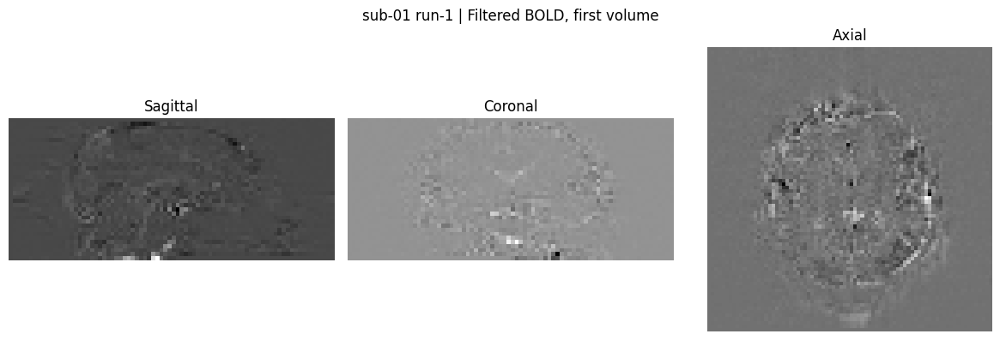

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_preproc_bold_dt_filt.nii.gz
shape: (80, 80, 35, 286)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.0))


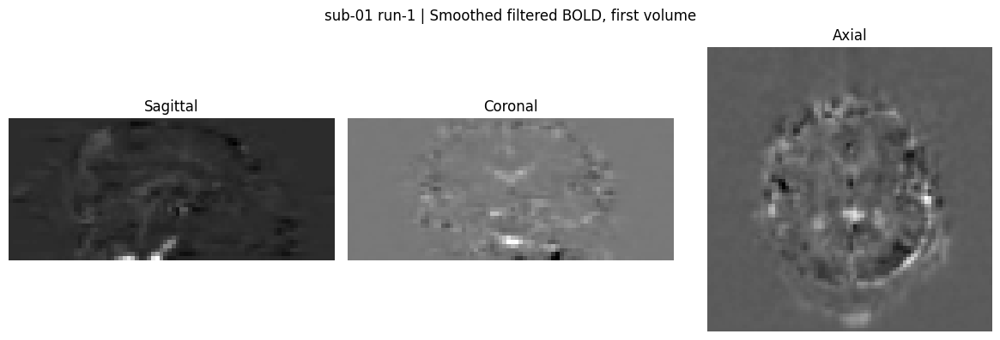

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_preproc_bold_dt_filt_sm4.nii.gz
shape: (80, 80, 35, 286)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(0.0))


In [64]:
row_s = df_smoothing_summary.query("subject == 'sub-01' and run == 'run-1'").iloc[0]

plot_orth(
    row_s["filtered_bold"],
    title="sub-01 run-1 | Filtered BOLD, first volume"
)

plot_orth(
    row_s["smoothed_filtered_bold"],
    title="sub-01 run-1 | Smoothed filtered BOLD, first volume"
)

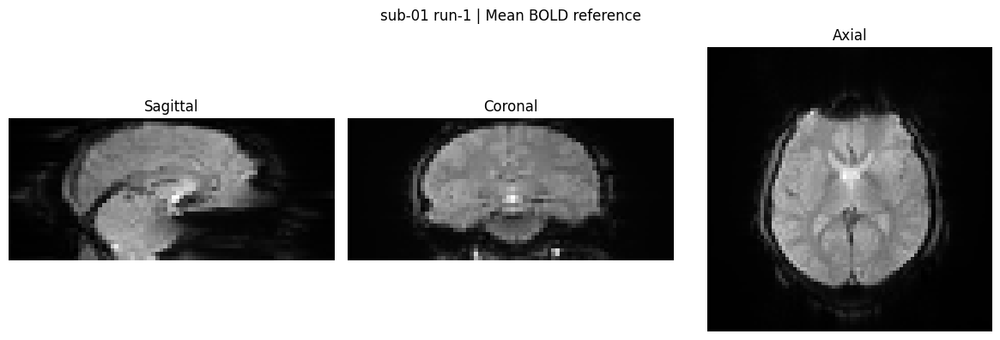

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/meansub-01_task-rest_run-1_bold_00001.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


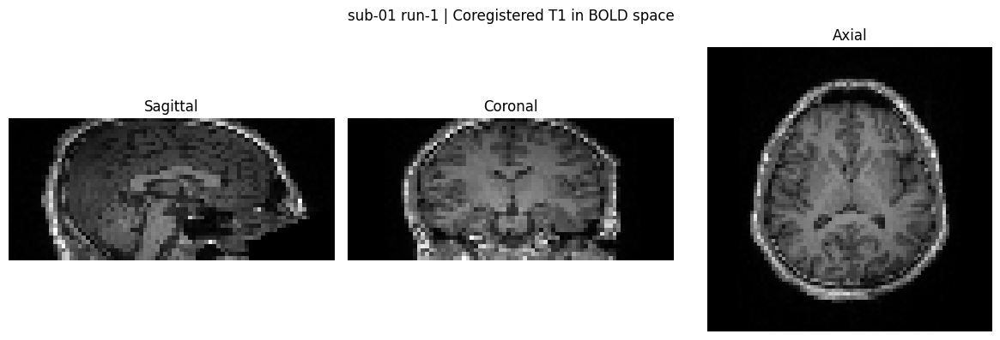

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


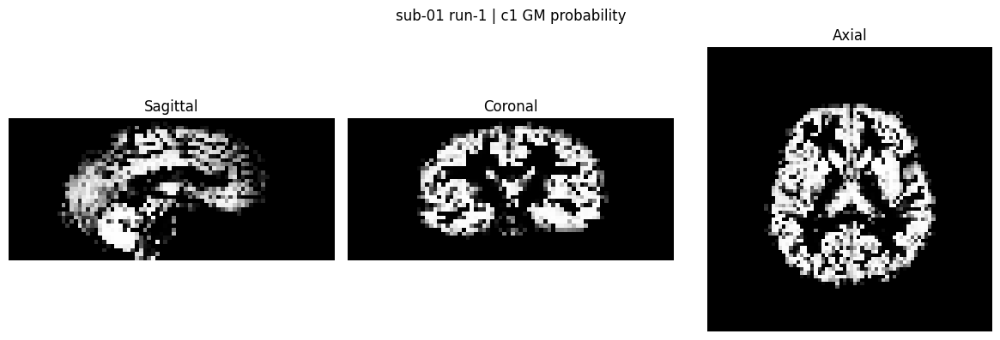

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c1rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


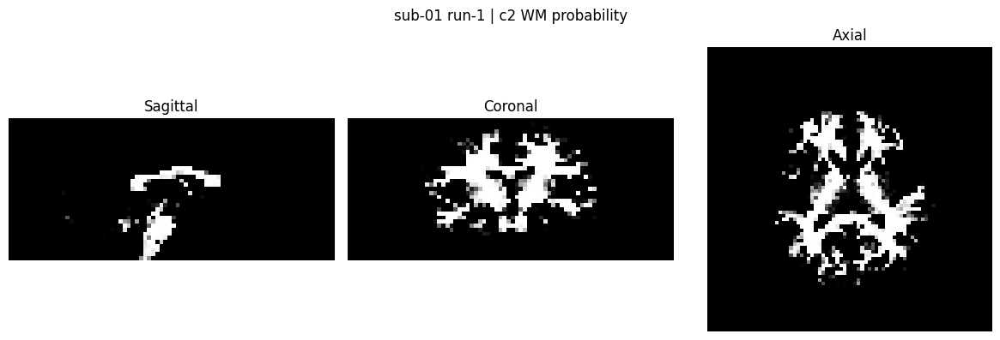

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c2rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


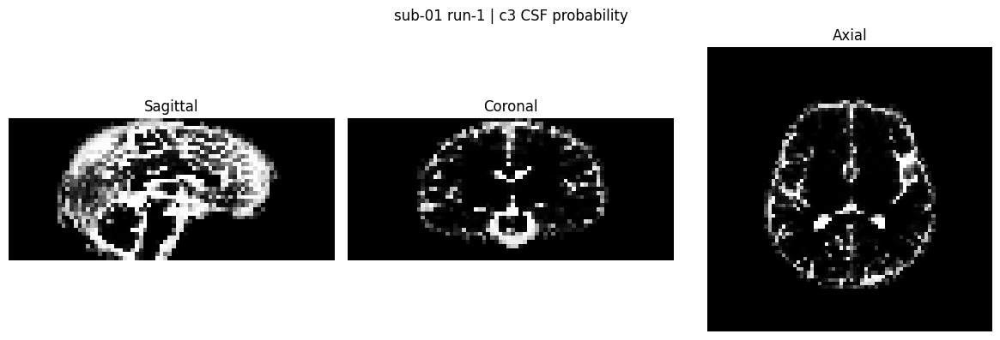

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c3rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


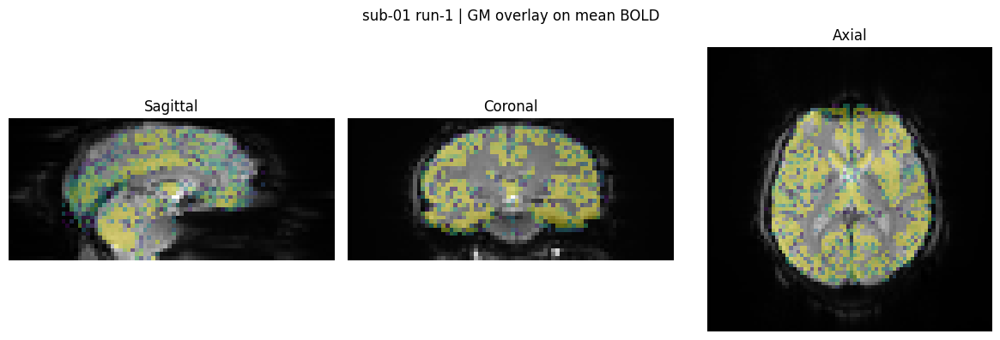

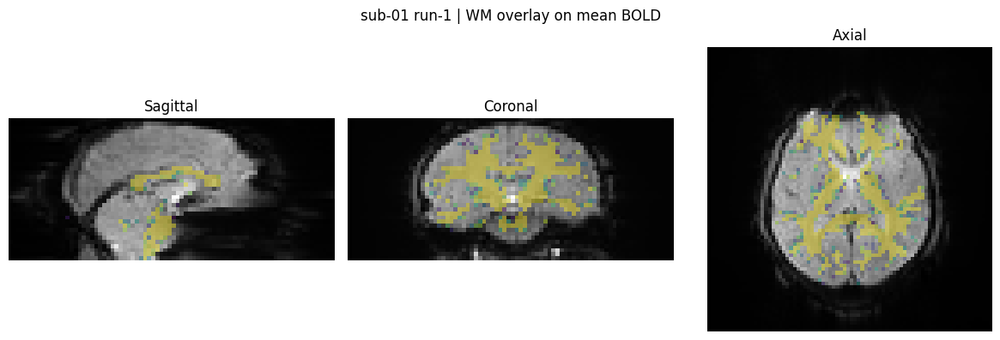

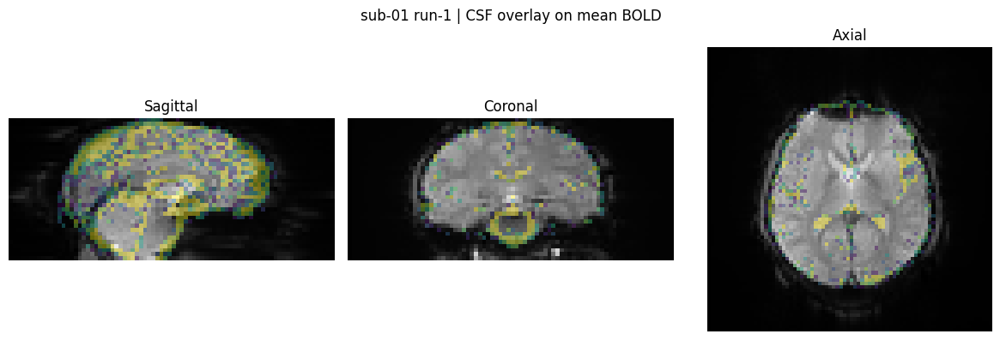

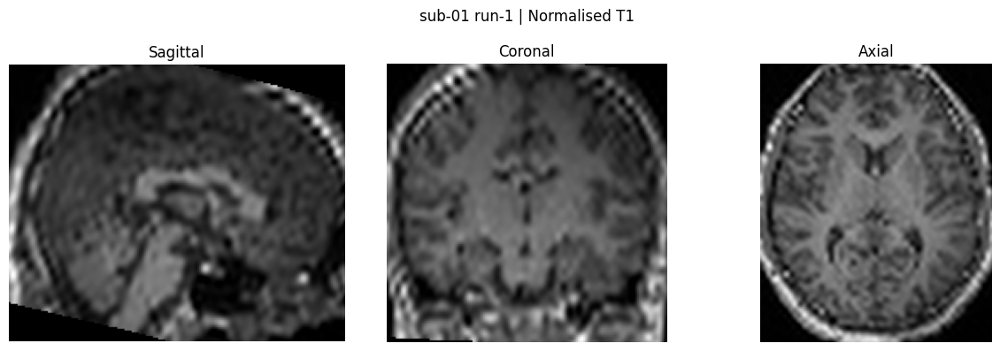

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/wrsub-01_T1w.nii
shape: (157, 189, 156)
zooms: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


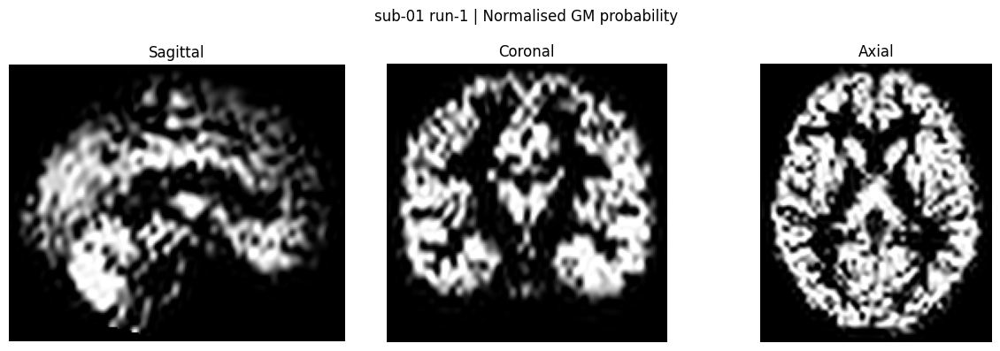

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/wc1rsub-01_T1w.nii
shape: (157, 189, 156)
zooms: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


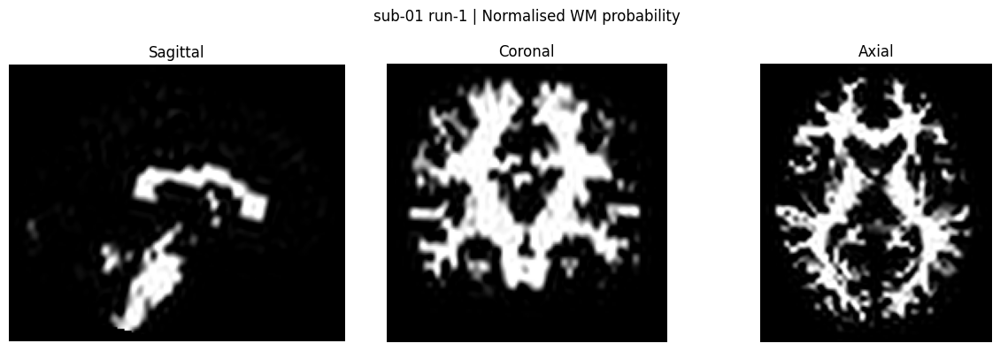

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/wc2rsub-01_T1w.nii
shape: (157, 189, 156)
zooms: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


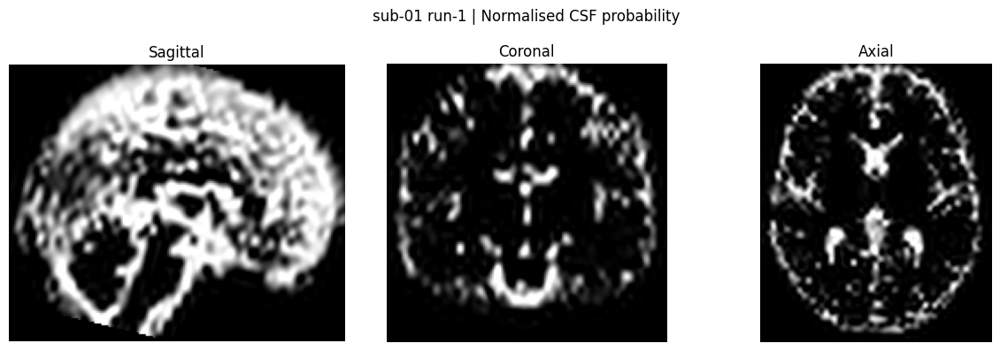

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/wc3rsub-01_T1w.nii
shape: (157, 189, 156)
zooms: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [29]:
plot_orth(row["mean_bold"], title="sub-01 run-1 | Mean BOLD reference")
plot_orth(row["coreg_t1"], title="sub-01 run-1 | Coregistered T1 in BOLD space")

plot_orth(row["c1"], title="sub-01 run-1 | c1 GM probability", vmin=0, vmax=1)
plot_orth(row["c2"], title="sub-01 run-1 | c2 WM probability", vmin=0, vmax=1)
plot_orth(row["c3"], title="sub-01 run-1 | c3 CSF probability", vmin=0, vmax=1)

plot_overlay(row["mean_bold"], row["c1"], title="sub-01 run-1 | GM overlay on mean BOLD", mask_thr=0.2)
plot_overlay(row["mean_bold"], row["c2"], title="sub-01 run-1 | WM overlay on mean BOLD", mask_thr=0.2)
plot_overlay(row["mean_bold"], row["c3"], title="sub-01 run-1 | CSF overlay on mean BOLD", mask_thr=0.2)

plot_orth(row["wr_t1"], title="sub-01 run-1 | Normalised T1")
plot_orth(row["wc1"], title="sub-01 run-1 | Normalised GM probability", vmin=0, vmax=1)
plot_orth(row["wc2"], title="sub-01 run-1 | Normalised WM probability", vmin=0, vmax=1)
plot_orth(row["wc3"], title="sub-01 run-1 | Normalised CSF probability", vmin=0, vmax=1)


===== sub-01 run-1 =====
coreg_t1: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/rsub-01_T1w.nii
c1      : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/c1rsub-01_T1w.nii
y       : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/y_rsub-01_T1w.nii
wr_t1   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/wrsub-01_T1w.nii


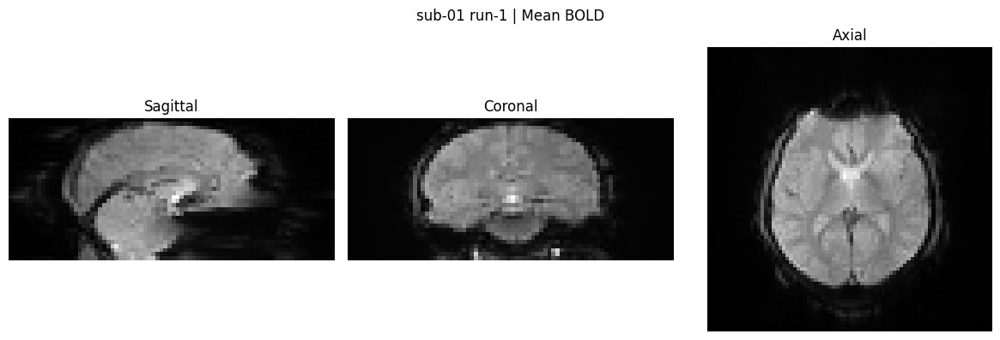

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/meansub-01_task-rest_run-1_bold_00001.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


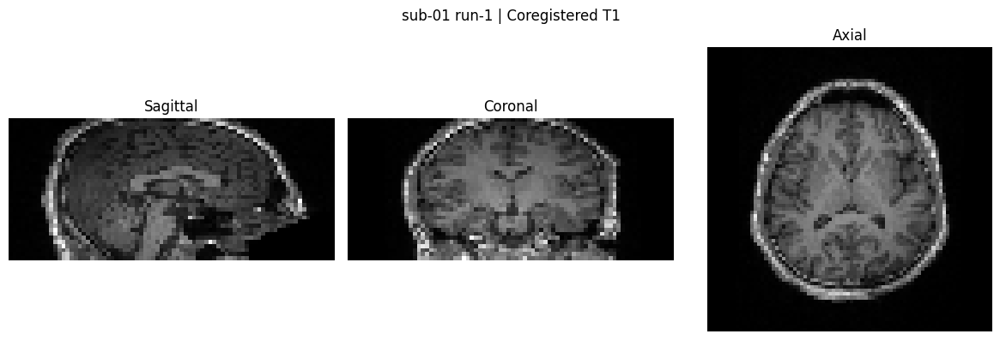

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/anat/rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


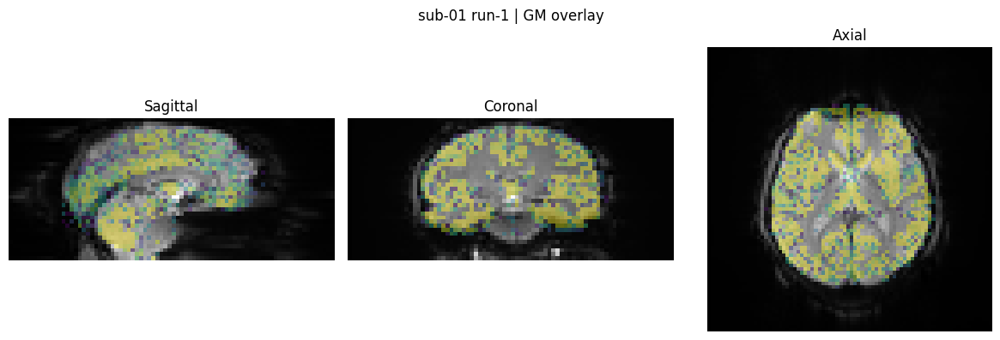


===== sub-01 run-2 =====
coreg_t1: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-2/anat/rsub-01_T1w.nii
c1      : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-2/anat/c1rsub-01_T1w.nii
y       : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-2/anat/y_rsub-01_T1w.nii
wr_t1   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-2/anat/wrsub-01_T1w.nii


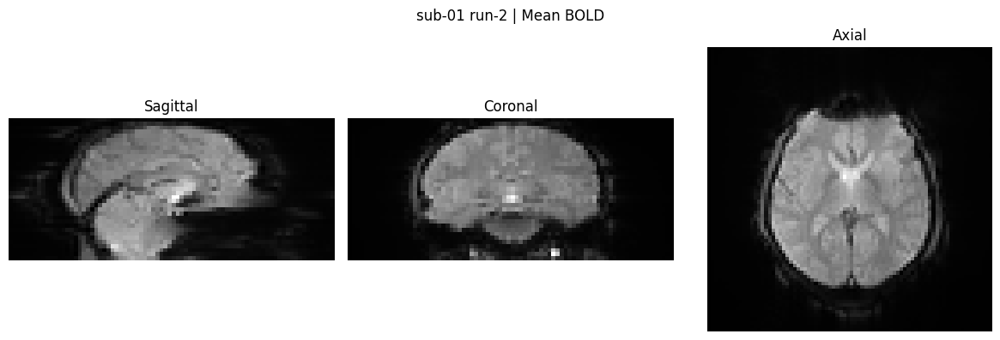

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-2/meansub-01_task-rest_run-2_bold_00001.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


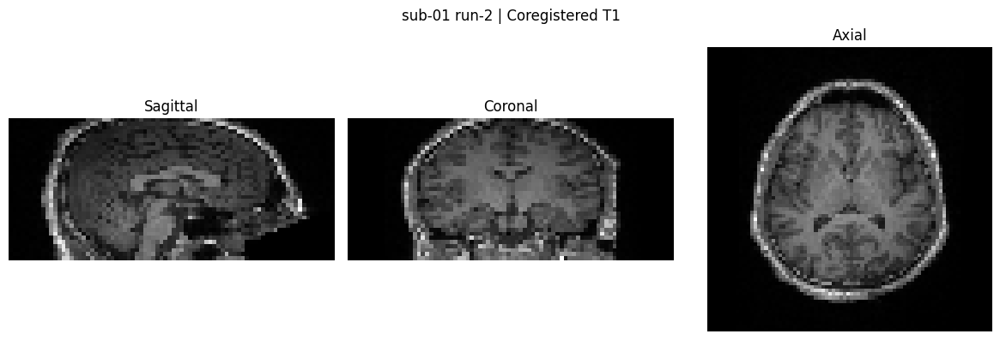

file : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-2/anat/rsub-01_T1w.nii
shape: (80, 80, 35)
zooms: (np.float32(3.0), np.float32(3.0), np.float32(4.0))


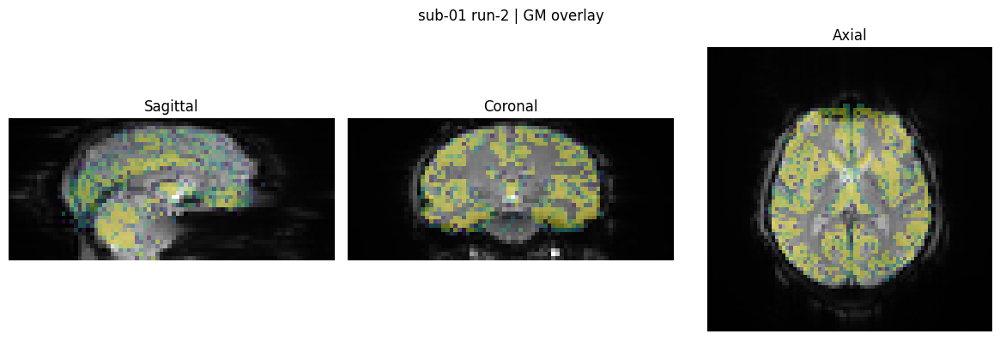

In [30]:
for run in ["run-1", "run-2"]:
    row = df_struct_summary.query("subject == 'sub-01' and run == @run").iloc[0]

    print(f"\n===== sub-01 {run} =====")
    print("coreg_t1:", row["coreg_t1"])
    print("c1      :", row["c1"])
    print("y       :", row["y"])
    print("wr_t1   :", row["wr_t1"])

    plot_orth(row["mean_bold"], title=f"sub-01 {run} | Mean BOLD")
    plot_orth(row["coreg_t1"], title=f"sub-01 {run} | Coregistered T1")
    plot_overlay(row["mean_bold"], row["c1"], title=f"sub-01 {run} | GM overlay", mask_thr=0.2)


===== sub-01 run-1 =====


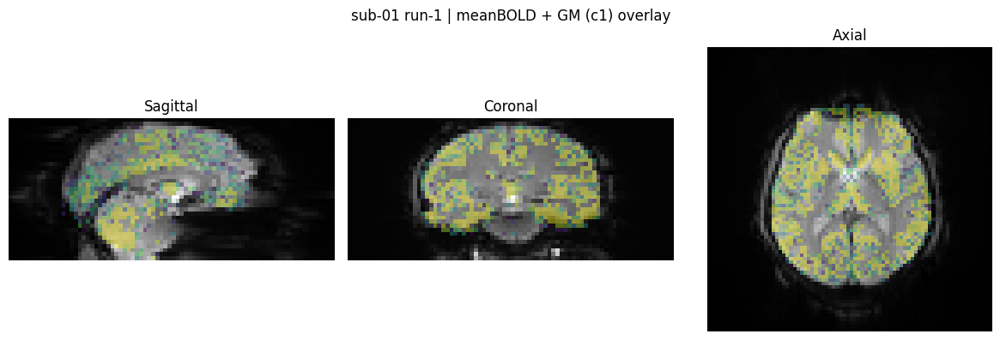

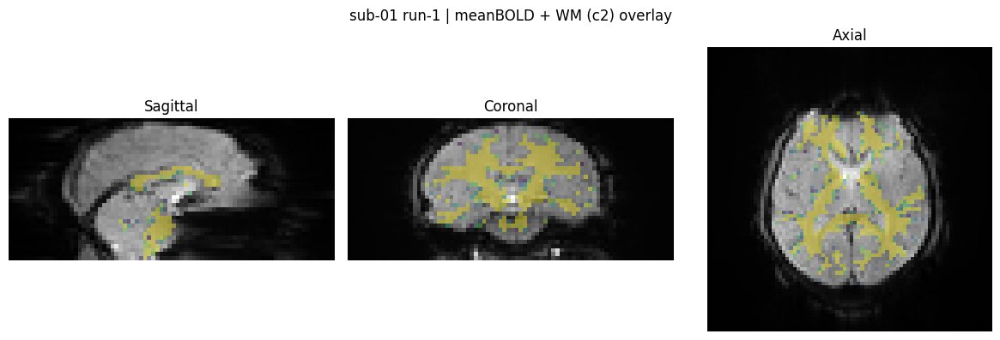

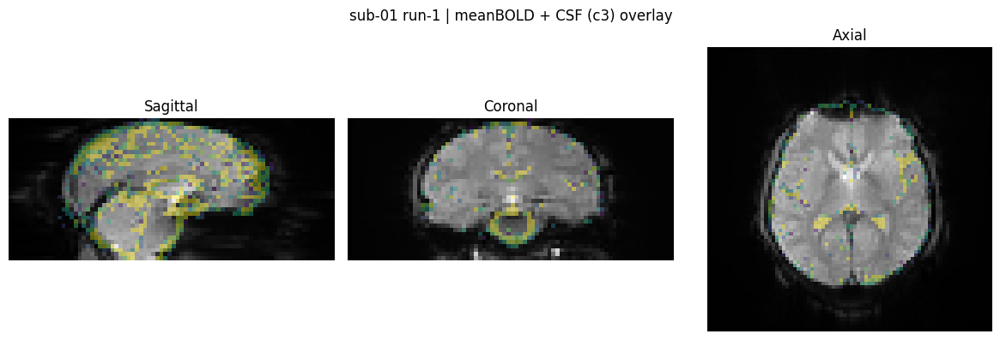


===== sub-02 run-1 =====


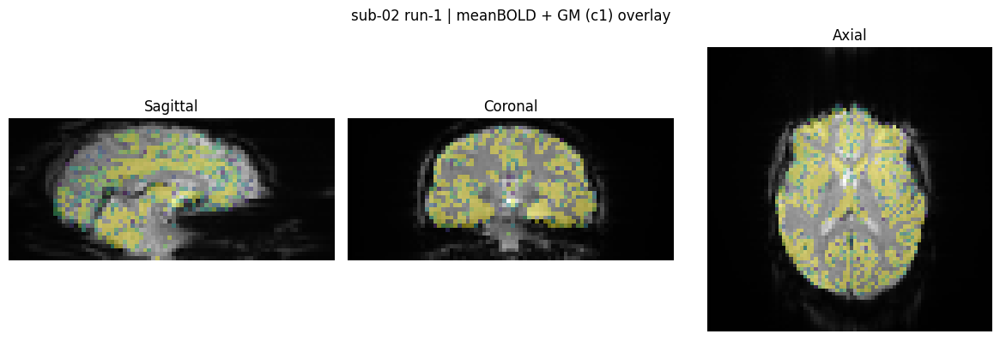

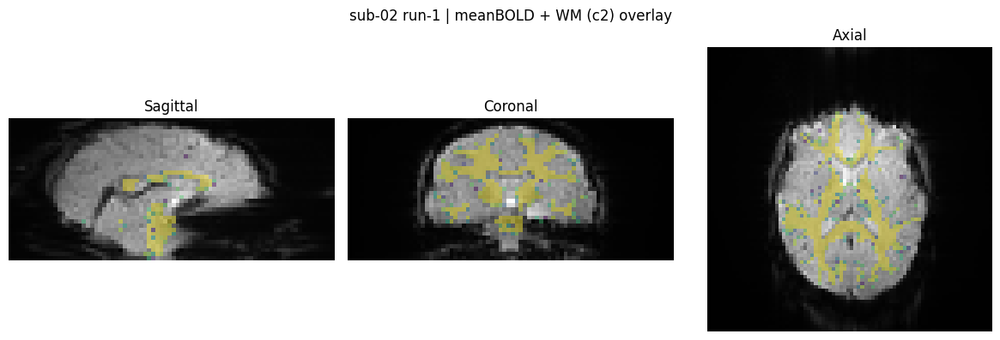

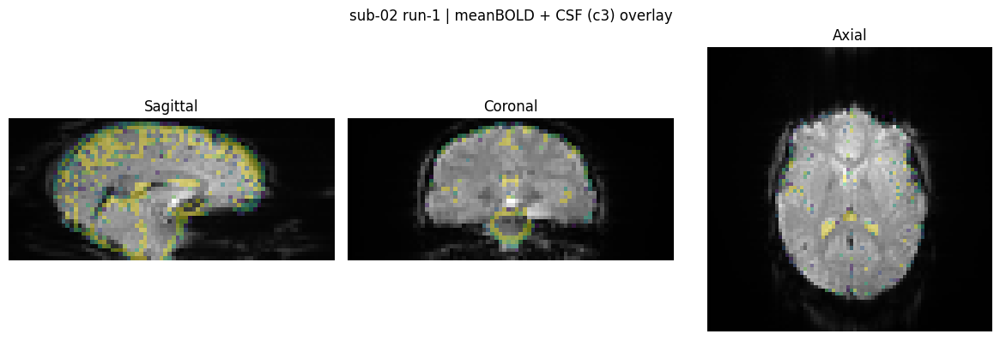


===== sub-03 run-1 =====


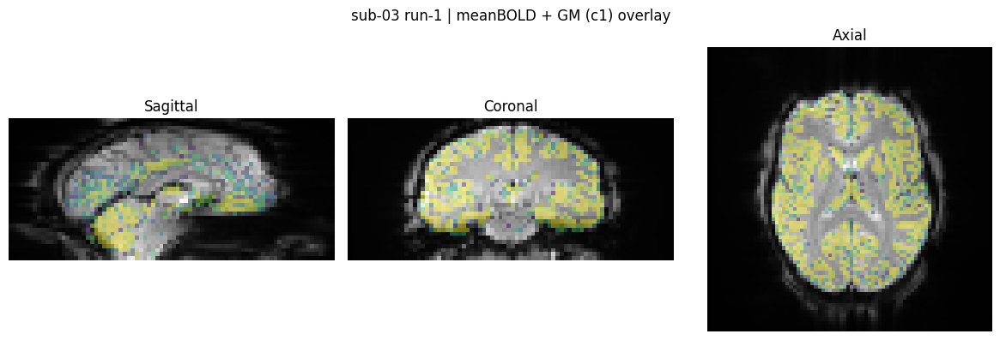

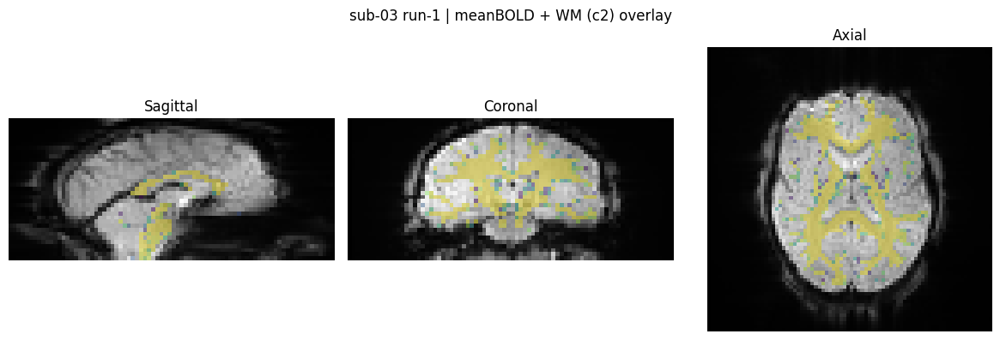

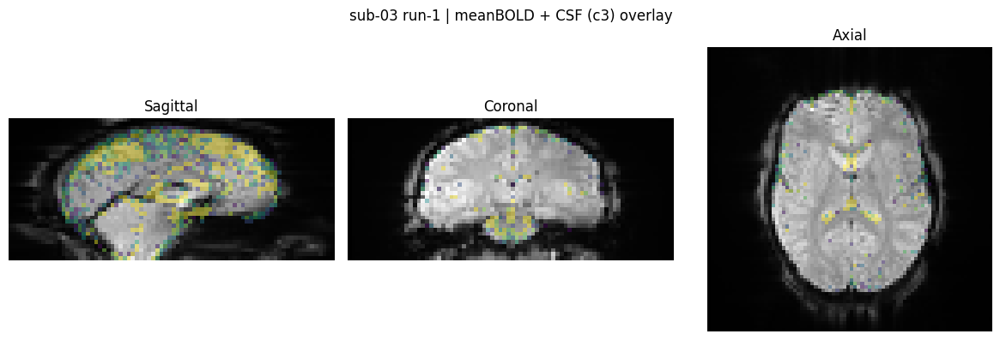


===== sub-04 run-1 =====


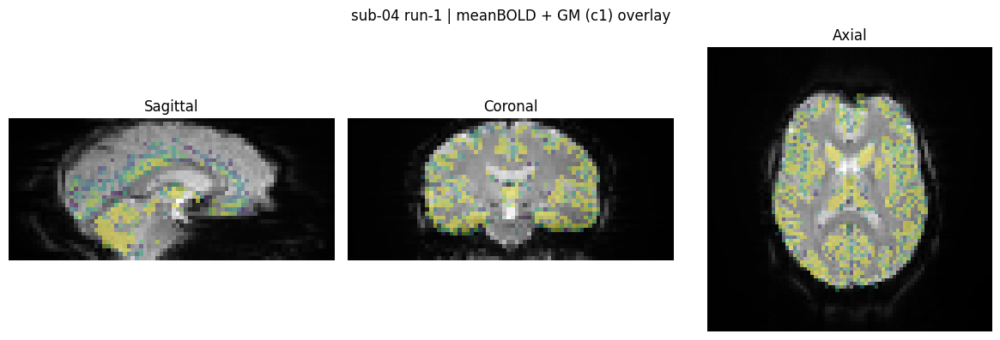

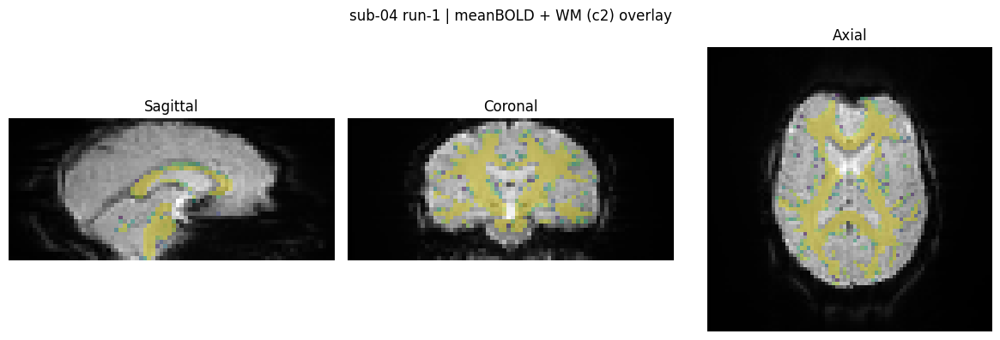

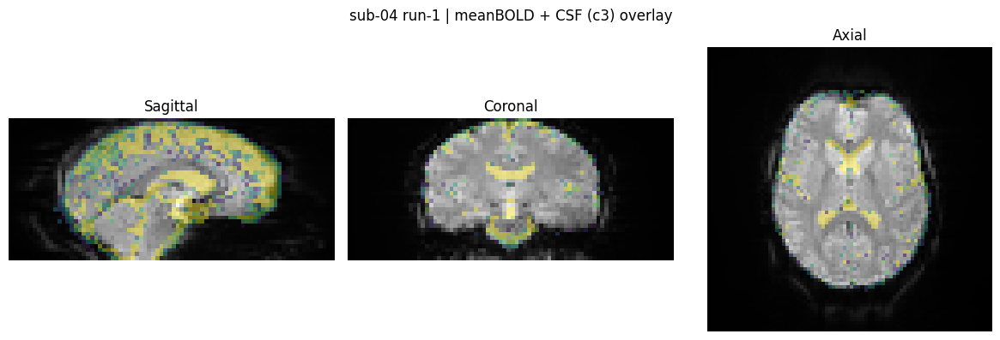


===== sub-05 run-1 =====


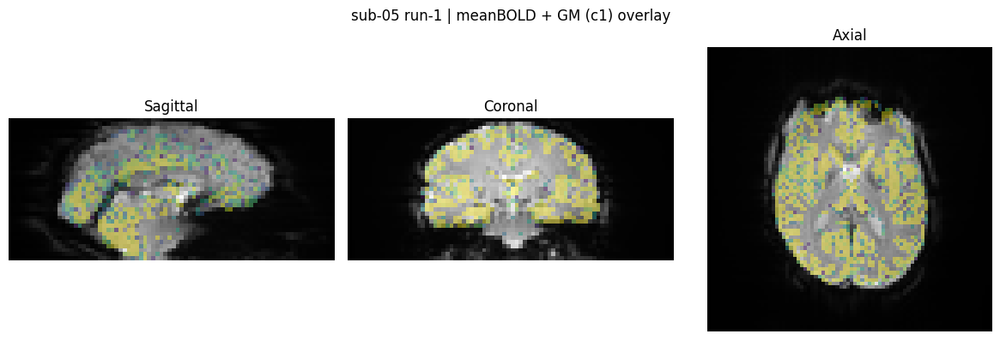

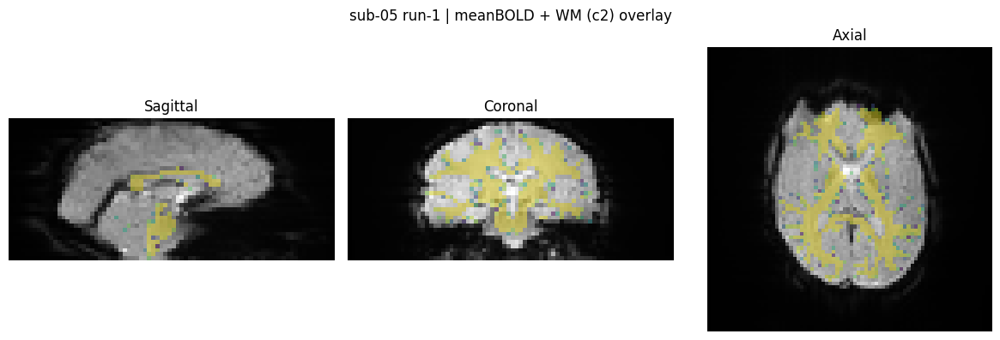

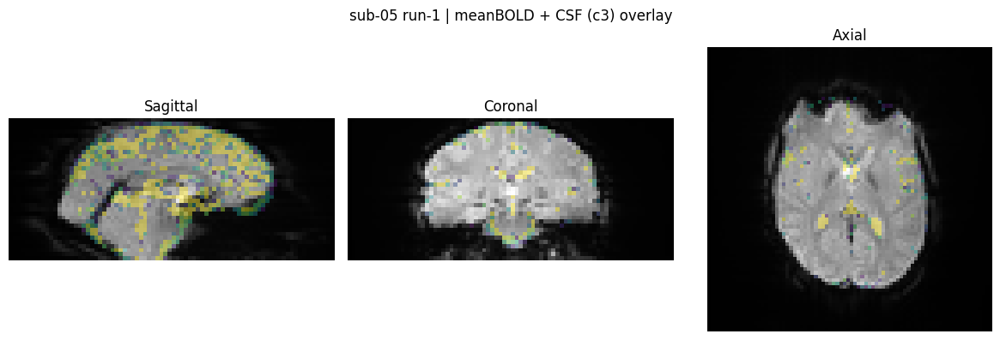

In [40]:
# meanBOLD --> mask overlay
thr = 0.5


sample_rows = (
    df_struct_summary
    .sort_values(["subject", "run"])
    .groupby("subject")
    .head(1)
    .head(5)
)

for _, row in sample_rows.iterrows():
    title_prefix = f"{row['subject']} {row['run']}"

    print(f"\n===== {title_prefix} =====")
    plot_overlay(row["mean_bold"], row["c1"], title=f"{title_prefix} | meanBOLD + GM (c1) overlay"
                 , mask_thr=thr)
    plot_overlay(row["mean_bold"], row["c2"], title=f"{title_prefix} | meanBOLD + WM (c2) overlay"
                 , mask_thr=thr)
    plot_overlay(row["mean_bold"], row["c3"], title=f"{title_prefix} | meanBOLD + CSF (c3) overlay"
                 , mask_thr=thr)
    


===== sub-01 run-1 =====


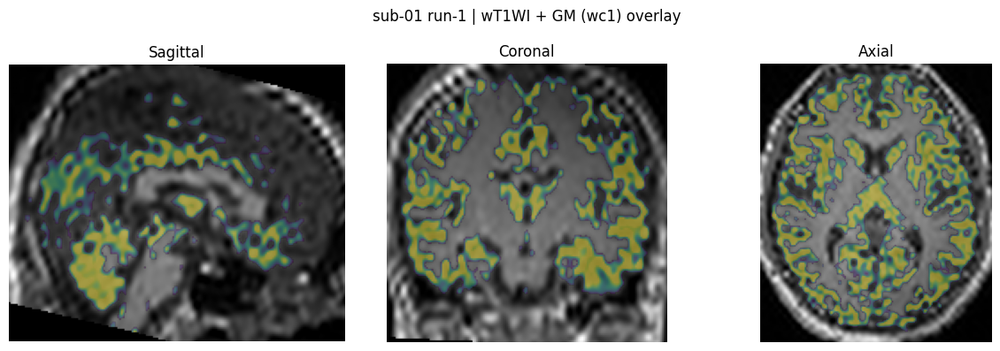

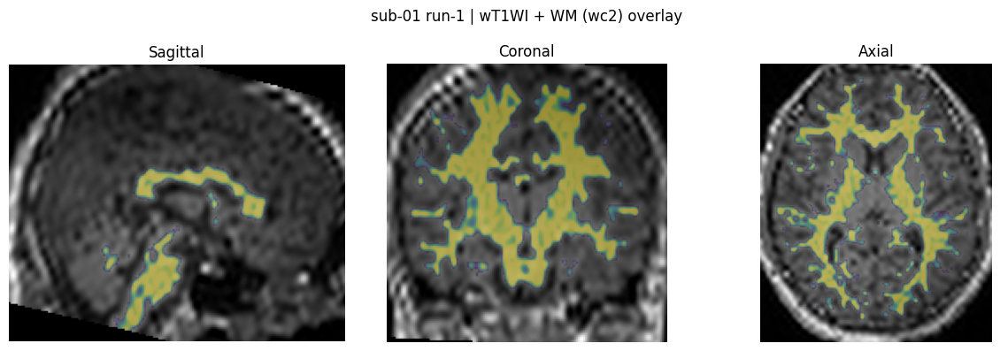

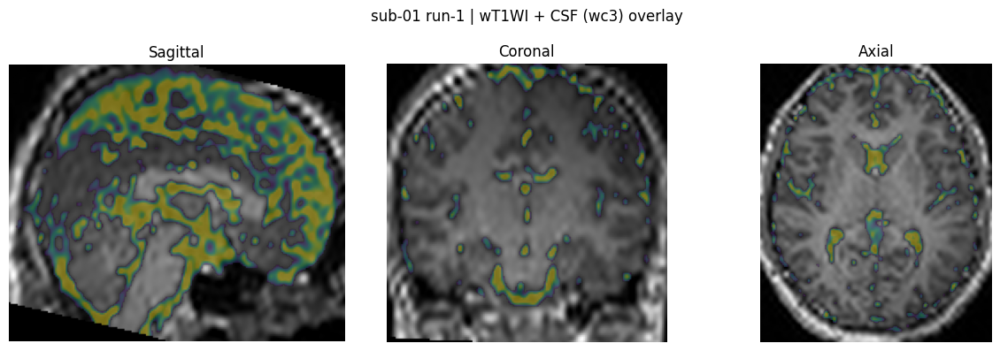


===== sub-02 run-1 =====


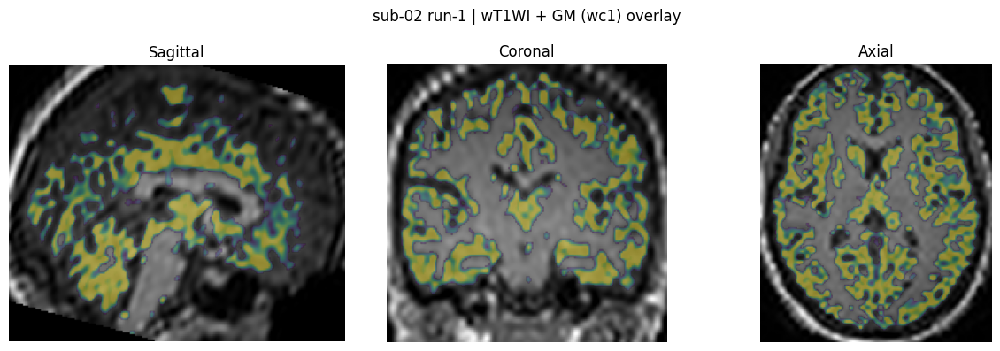

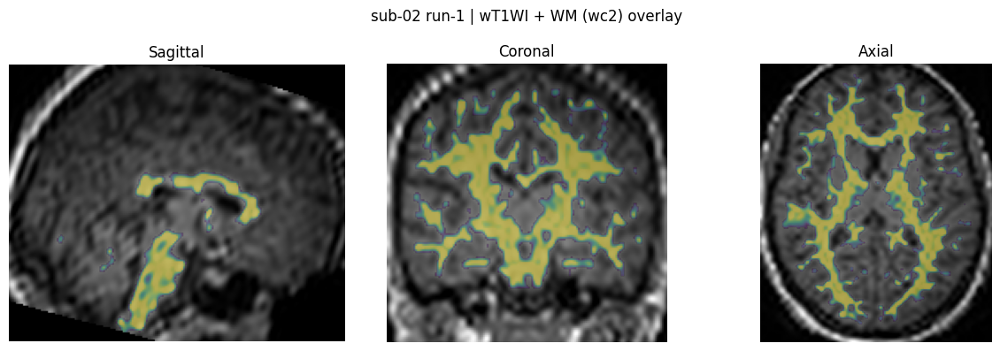

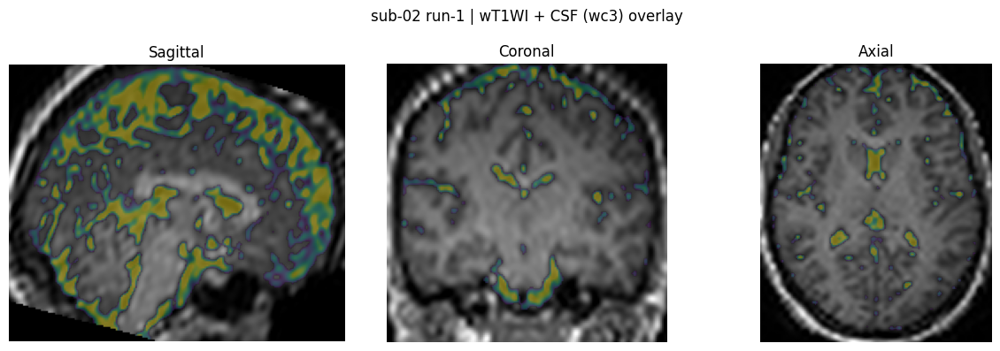


===== sub-03 run-1 =====


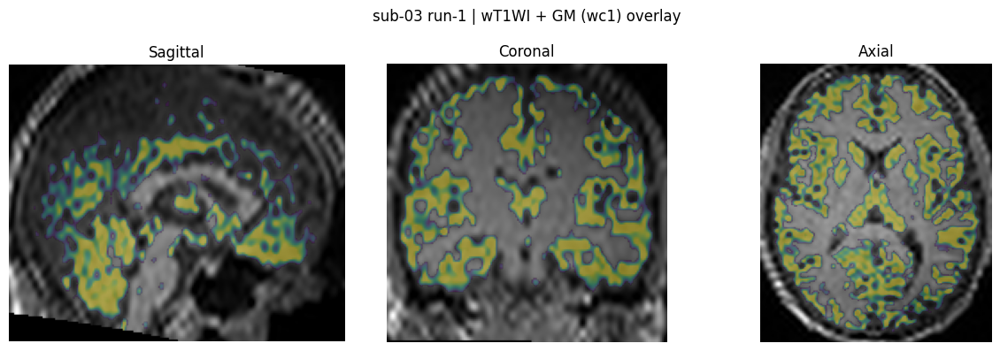

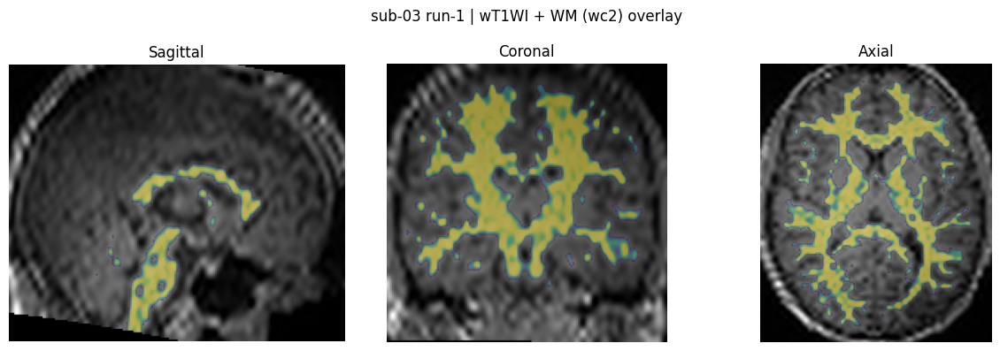

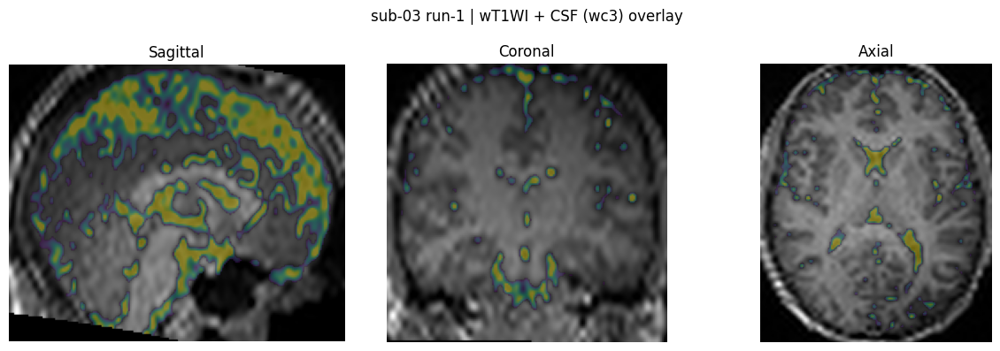


===== sub-04 run-1 =====


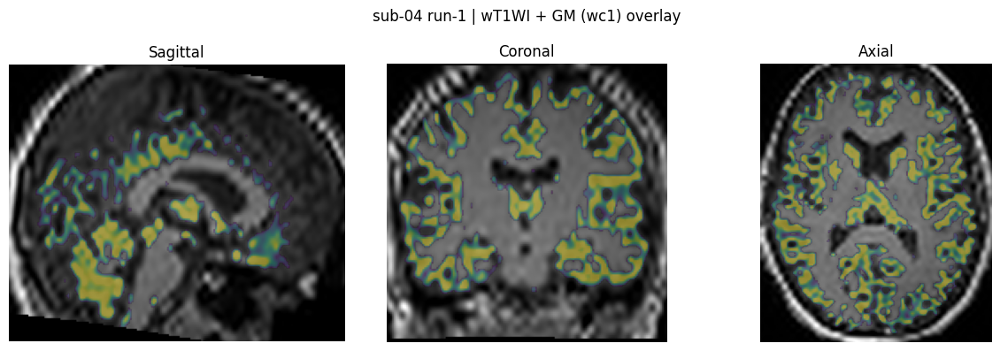

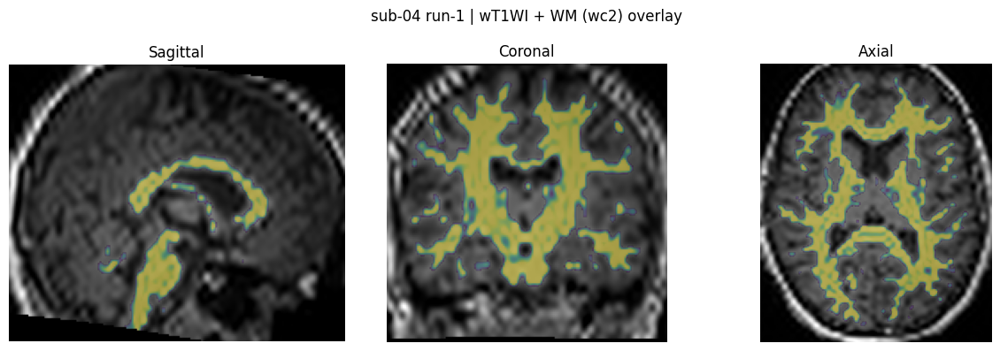

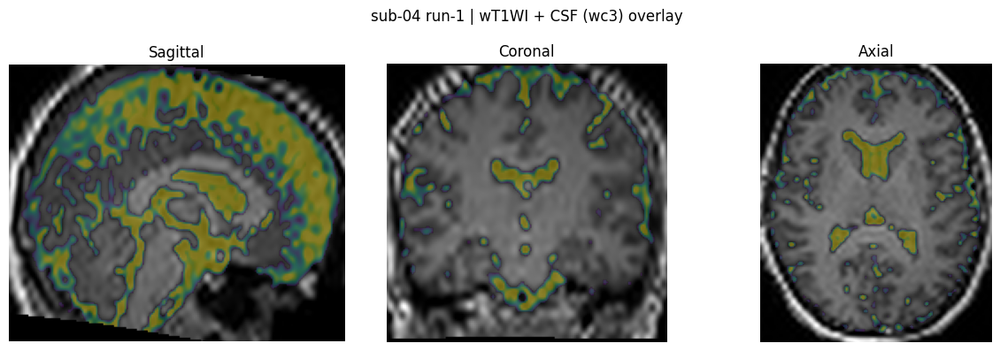


===== sub-05 run-1 =====


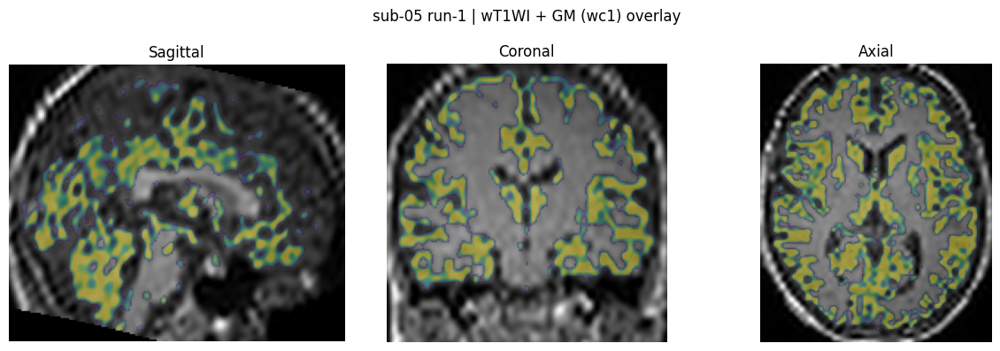

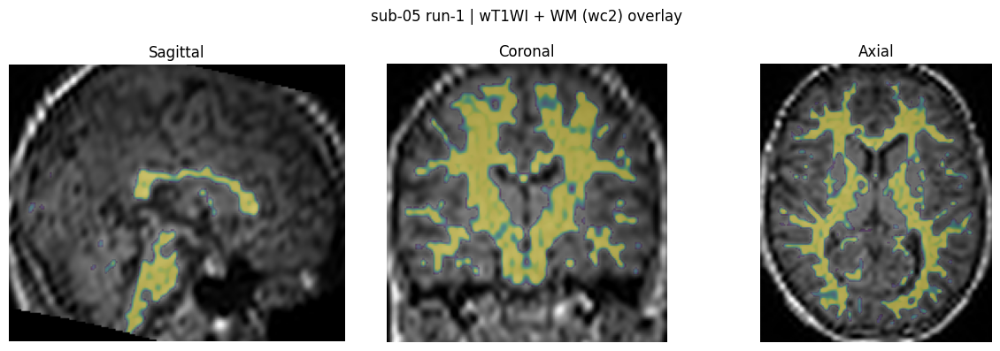

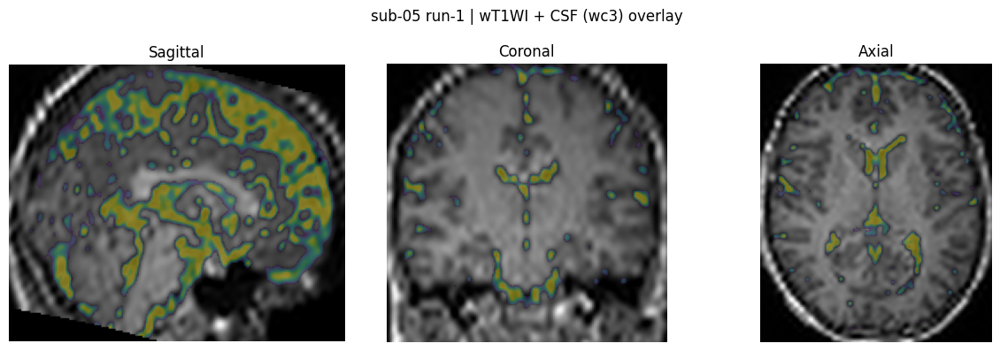

In [39]:
# wT1WI --> normalised mask overlay

# thr = 0.5

sample_rows = (
    df_struct_summary
    .sort_values(["subject", "run"])
    .groupby("subject")
    .head(1)
    .head(5)
)

for _, row in sample_rows.iterrows():
    title_prefix = f"{row['subject']} {row['run']}"
    print(f"\n===== {title_prefix} =====")
    plot_overlay(row["wr_t1"], row["wc1"], title=f"{title_prefix} | wT1WI + GM (wc1) overlay", mask_thr=thr)
    plot_overlay(row["wr_t1"], row["wc2"], title=f"{title_prefix} | wT1WI + WM (wc2) overlay", mask_thr=thr)
    plot_overlay(row["wr_t1"], row["wc3"], title=f"{title_prefix} | wT1WI + CSF (wc3) overlay", mask_thr=thr)

In [41]:
# Check whether normalised mean BOLD exists

wmean_rows = []

for _, row in df_struct_summary.iterrows():
    mean_path = Path(row["mean_bold"])
    wmean_path = mean_path.parent / f"w{mean_path.name}"

    wmean_rows.append({
        "subject": row["subject"],
        "run": row["run"],
        "mean_bold": str(mean_path),
        "wmean_bold": str(wmean_path),
        "wmean_exists": wmean_path.exists(),
    })

df_wmean_check = pd.DataFrame(wmean_rows)

print(df_wmean_check["wmean_exists"].value_counts(dropna=False))
display(df_wmean_check.head())
display(df_wmean_check.loc[~df_wmean_check["wmean_exists"]].head())

wmean_exists
False    66
Name: count, dtype: int64


,subject,run,mean_bold,wmean_bold,wmean_exists
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False


,subject,run,mean_bold,wmean_bold,wmean_exists
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
2,sub-02,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
3,sub-02,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
4,sub-03,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,False
